# IT5006 Milestone 3: Predictive Policing in Chicago
## Team 11 — Yizhuo Zhang, Lin Xuan Foo, Yiding Cui, Yinan Jin, Xinyao Tan
### National University of Singapore · AY2025/2026 Semester 2

**Objective:** Build and evaluate predictive models to forecast crime hotspots in Chicago, enabling data-driven police resource allocation.

**Models:** Logistic Regression (baseline), Random Forest, XGBoost, LSTM

**Dataset:** Chicago Crime Data (2018-2025), 1.95M records from the Chicago Data Portal

---
## 1. Environment Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve)
import xgboost as xgb

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Explainability
import shap

# Holiday calendar & statistical testing
from pandas.tseries.holiday import USFederalHolidayCalendar
from scipy import stats


In [2]:
# Settings
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("Environment ready!")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Scikit-learn: {__import__('sklearn').__version__}")
print(f"XGBoost: {xgb.__version__}")
print(f"TensorFlow: {tf.__version__}")
print(f"SHAP: {shap.__version__}")

Environment ready!
NumPy: 2.4.4
Pandas: 3.0.2
Scikit-learn: 1.8.0
XGBoost: 3.2.0
TensorFlow: 2.21.0
SHAP: 0.51.0


---
## 2. Data Loading and Initial Exploration

We load the Chicago crime dataset (2018-2025) from the Chicago Data Portal. The dataset contains over 1.9 million crime incident records with spatial, temporal, and categorical information.

In [3]:
# Data source switch: prefer local file by default; enable download only when needed
import os, requests, time

USE_ONLINE_DOWNLOAD = False
LOCAL_CSV_CANDIDATES = [
    'data/chicago_crimes_2018_2025.csv',
    # 'data/chicago_crime_2018_2025.csv',
]

os.makedirs('data', exist_ok=True)
csv_path = None
for cand in LOCAL_CSV_CANDIDATES:
    if os.path.exists(cand):
        csv_path = cand
        break
if csv_path is None:
    csv_path = LOCAL_CSV_CANDIDATES[0]

if not USE_ONLINE_DOWNLOAD:
    if not os.path.exists(csv_path):
        raise FileNotFoundError(
            f"No local file found in {LOCAL_CSV_CANDIDATES}. Set USE_ONLINE_DOWNLOAD=True to fetch from portal."
        )
    print(f"Using local data file: {csv_path}")
else:
    if os.path.exists(csv_path):
        print(f'Data already exists at {csv_path}, skipping download.')
    else:
        print(' Downloading from Chicago Data Portal (this may take a few minutes)...')
        BASE = 'https://data.cityofchicago.org/resource/ijzp-q8t2.csv'
        LIMIT = 50000
        WHERE = "date >= '2018-01-01T00:00:00'"

        all_chunks = []
        offset = 0
        while True:
            params = {
                '$where': WHERE,
                '$limit': LIMIT,
                '$offset': offset,
                '$order': ':id'
            }
            r = requests.get(BASE, params=params, timeout=120)
            r.raise_for_status()
            chunk = r.text
            n_rows = chunk.count('\n') - 1
            if offset == 0:
                all_chunks.append(chunk)
            else:
                all_chunks.append(chunk.split('\n', 1)[1])
            print(f'  Fetched rows {offset:,} - {offset + n_rows:,}')
            if n_rows < LIMIT:
                break
            offset += LIMIT
            time.sleep(1)

        with open(csv_path, 'w') as f:
            f.write(''.join(all_chunks))
        print(f' Saved to {csv_path}')


Using local data file: data/chicago_crimes_2018_2025.csv


In [4]:
import pandas as pd
print(pd.read_csv(csv_path, nrows=2).columns.tolist())


['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude', 'Location']


In [5]:
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

# Rename SODA API lowercase columns to expected format
if 'date' in df.columns:
    RENAME_MAP = {
        'id': 'ID', 'case_number': 'Case Number', 'date': 'Date',
        'block': 'Block', 'iucr': 'IUCR', 'primary_type': 'Primary Type',
        'description': 'Description', 'location_description': 'Location Description',
        'arrest': 'Arrest', 'domestic': 'Domestic', 'beat': 'Beat',
        'district': 'District', 'ward': 'Ward', 'community_area': 'Community Area',
        'fbi_code': 'FBI Code', 'x_coordinate': 'X Coordinate',
        'y_coordinate': 'Y Coordinate', 'year': 'Year',
        'updated_on': 'Updated On', 'latitude': 'Latitude',
        'longitude': 'Longitude', 'location': 'Location'
    }
    df.rename(columns=RENAME_MAP, inplace=True)
    print("Renamed SODA columns to expected format.")

df['Date'] = pd.to_datetime(df['Date'])
print(f"Dataset Shape: {df.shape}")
print(f"Date Range: {df['Date'].min()} to {df['Date'].max()}")
print(f"\nColumn Types:")
print(df.dtypes)
print(f"\nMissing Values (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))


Dataset Shape: (1952393, 22)
Date Range: 2018-01-01 00:01:00 to 2025-12-31 23:58:00

Column Types:
ID                               int64
Case Number                        str
Date                    datetime64[us]
Block                              str
IUCR                               str
Primary Type                       str
Description                        str
Location Description               str
Arrest                            bool
Domestic                          bool
Beat                             int64
District                         int64
Ward                           float64
Community Area                 float64
FBI Code                           str
X Coordinate                   float64
Y Coordinate                   float64
Year                             int64
Updated On                         str
Latitude                       float64
Longitude                      float64
Location                           str
dtype: object

Missing Values (top 10):
Loc

In [6]:
# Quick overview of the data
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total Records: {len(df):,}")
print(f"\nTop 10 Crime Types:")
print(df['Primary Type'].value_counts().head(10).to_string())
print(f"\nArrest Rate: {df['Arrest'].mean():.2%}")
print(f"Domestic Rate: {df['Domestic'].mean():.2%}")

DATASET OVERVIEW
Total Records: 1,952,393

Top 10 Crime Types:
Primary Type
THEFT                  438006
BATTERY                355279
CRIMINAL DAMAGE        216590
ASSAULT                168136
DECEPTIVE PRACTICE     141677
MOTOR VEHICLE THEFT    129202
OTHER OFFENSE          124890
BURGLARY                70045
ROBBERY                 68386
NARCOTICS               65204

Arrest Rate: 15.63%
Domestic Rate: 19.57%


---
## 3. Data Preprocessing and Feature Engineering

### 3.1 Data Cleaning
We remove records with invalid coordinates and classify crimes into categories: **Property**, **Violent**, **Sexual**, and **Other**.

In [7]:
# Data Cleaning
df = df.dropna(subset=['Latitude', 'Longitude', 'Community Area'])
df = df[(df['Latitude'] > 41.6) & (df['Latitude'] < 42.1)]
df = df[(df['Longitude'] > -87.95) & (df['Longitude'] < -87.5)]
print(f"After cleaning: {len(df):,} records")

# Crime Category Classification
PROPERTY = ['THEFT','BURGLARY','MOTOR VEHICLE THEFT','ROBBERY','ARSON',
            'CRIMINAL DAMAGE','DECEPTIVE PRACTICE']
VIOLENT = ['BATTERY','ASSAULT','HOMICIDE','KIDNAPPING',
           'WEAPONS VIOLATION','INTIMIDATION']
SEXUAL = ['CRIM SEXUAL ASSAULT','SEX OFFENSE','STALKING',
          'HUMAN TRAFFICKING','PROSTITUTION']

def classify_crime(pt):
    if pt in PROPERTY: return 'PROPERTY'
    elif pt in VIOLENT: return 'VIOLENT'
    elif pt in SEXUAL: return 'SEXUAL'
    else: return 'OTHER'

df['crime_category'] = df['Primary Type'].apply(classify_crime)
print(f"\nCrime Category Distribution:")
print(df['crime_category'].value_counts().to_string())
print(f"\nProperty + Violent = {(df['crime_category'].isin(['PROPERTY','VIOLENT'])).mean():.1%} of all crimes")

After cleaning: 1,922,491 records

Crime Category Distribution:
crime_category
PROPERTY    1047924
VIOLENT      588558
OTHER        268584
SEXUAL        17425

Property + Violent = 85.1% of all crimes


### 3.2 Feature Engineering

We engineer temporal, spatial, historical lag, and contextual features to capture the complex dynamics of crime patterns.

#### 3.2.1 Temporal and Holiday Features

In [8]:
# Temporal + Calendar + Historical Feature Engineering (no grid-neighbor features)
df['hour'] = df['Date'].dt.hour
df['day_of_week'] = df['Date'].dt.dayofweek
df['month'] = df['Date'].dt.month
df['day_of_month'] = df['Date'].dt.day
df['quarter'] = df['Date'].dt.quarter
df['year'] = df['Date'].dt.year
df['date_only'] = df['Date'].dt.date
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['is_night'] = df['hour'].isin(list(range(0, 6)) + list(range(21, 24))).astype(int)
df['time_period'] = pd.cut(df['hour'], bins=[0, 6, 12, 18, 24], labels=[0, 1, 2, 3], right=False).astype(int)
df['is_payday'] = df['day_of_month'].isin([1, 15]).astype(int)

# Cyclical encodings
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Federal holidays + Juneteenth observed + pre/post/long-weekend
cal = USFederalHolidayCalendar()
start = df['Date'].min().normalize() - pd.Timedelta(days=7)
end = df['Date'].max().normalize() + pd.Timedelta(days=7)
us_holidays = pd.DatetimeIndex(cal.holidays(start=start, end=end))

juneteenth_obs = []
for y in range(int(df['year'].min()), int(df['year'].max()) + 1):
    if y < 2021:
        continue
    d = pd.Timestamp(year=y, month=6, day=19)
    if d.dayofweek == 5:
        d = d - pd.Timedelta(days=1)
    elif d.dayofweek == 6:
        d = d + pd.Timedelta(days=1)
    juneteenth_obs.append(d)

holidays = pd.DatetimeIndex(sorted(set(us_holidays.tolist() + juneteenth_obs)))
date_norm = df['Date'].dt.normalize()
df['is_holiday'] = date_norm.isin(holidays).astype(int)
df['is_pre_holiday'] = (date_norm + pd.Timedelta(days=1)).isin(holidays).astype(int)
df['is_post_holiday'] = (date_norm - pd.Timedelta(days=1)).isin(holidays).astype(int)
df['is_long_weekend'] = ((df['is_weekend'] == 1) | (df['is_holiday'] == 1) |
                         (df['is_pre_holiday'] == 1) | (df['is_post_holiday'] == 1)).astype(int)


#### 3.2.2 Crime Type Bucketization & Primary Aggregation

In [9]:
# Top-K primary type bucket for one-hot encoding
top_k_types = df['Primary Type'].value_counts().nlargest(8).index
df['primary_type_topk'] = np.where(df['Primary Type'].isin(top_k_types), df['Primary Type'], 'OTHER')

# Aggregate to spatiotemporal units
agg_df = df.groupby(['Community Area', 'date_only', 'time_period', 'crime_category', 'primary_type_topk', 'year']).agg(
    crime_count=('ID', 'count'),
    hour_mean=('hour', 'mean'),
    day_of_week=('day_of_week', 'first'),
    month=('month', 'first'),
    day_of_month=('day_of_month', 'first'),
    quarter=('quarter', 'first'),
    is_weekend=('is_weekend', 'first'),
    is_night=('is_night', 'max'),
    is_payday=('is_payday', 'first'),
    is_holiday=('is_holiday', 'first'),
    is_pre_holiday=('is_pre_holiday', 'first'),
    is_post_holiday=('is_post_holiday', 'first'),
    is_long_weekend=('is_long_weekend', 'first'),
    hour_sin=('hour_sin', 'mean'),
    hour_cos=('hour_cos', 'mean'),
    dow_sin=('dow_sin', 'first'),
    dow_cos=('dow_cos', 'first'),
    lat_mean=('Latitude', 'mean'),
    lon_mean=('Longitude', 'mean')
).reset_index()



#### 3.2.3 Time-Series Extraction (Daily Rolling & Lags)

In [10]:
# Historical lag/trend/volatility features (shifted to avoid leakage)
daily_ca = df.groupby(['Community Area', 'date_only']).agg(
    daily_count=('ID', 'count'),
    daily_arrest=('Arrest', 'sum'),
    daily_domestic=('Domestic', 'sum')
).reset_index()

# Convert date_only to datetime for reindexing
daily_ca['date_only'] = pd.to_datetime(daily_ca['date_only'])

# Create a complete combination of all Community Areas and all dates
all_areas = daily_ca['Community Area'].unique()
date_range = pd.date_range(start=daily_ca['date_only'].min(), end=daily_ca['date_only'].max(), freq='D')
full_idx = pd.MultiIndex.from_product([all_areas, date_range], names=['Community Area', 'date_only'])

# Reindex and fill missing days with 0 (since no records means 0 crimes)
daily_ca = daily_ca.set_index(['Community Area', 'date_only']).reindex(full_idx, fill_value=0).reset_index()
daily_ca['date_only'] = daily_ca['date_only'].dt.date # Revert back to date format to match agg_df

daily_ca = daily_ca.sort_values(['Community Area', 'date_only'])

# Now we can safely use row-based shift/rolling, because 1 row == exactly 1 day
daily_ca['lag_1d'] = daily_ca.groupby('Community Area')['daily_count'].shift(1)
daily_ca['lag_7d'] = daily_ca.groupby('Community Area')['daily_count'].shift(7)

for win in [7, 14, 30]:
    daily_ca[f'rolling_{win}d'] = daily_ca.groupby('Community Area')['daily_count'].transform(
        lambda x: x.rolling(win, min_periods=1).mean().shift(1)
    )

daily_ca['rolling_std_7d'] = daily_ca.groupby('Community Area')['daily_count'].transform(
    lambda x: x.rolling(7, min_periods=1).std().shift(1)
)
daily_ca['rolling_std_30d'] = daily_ca.groupby('Community Area')['daily_count'].transform(
    lambda x: x.rolling(30, min_periods=1).std().shift(1)
)

daily_ca['crime_trend'] = daily_ca['rolling_7d'] / daily_ca['rolling_30d'].clip(lower=0.1)
daily_ca['spike_7_30'] = (daily_ca['rolling_7d'] - daily_ca['rolling_30d']) / daily_ca['rolling_30d'].clip(lower=0.1)

daily_ca['arrest_count'] = daily_ca.groupby('Community Area')['daily_arrest'].transform(
    lambda x: x.rolling(7, min_periods=1).sum().shift(1)
)
daily_ca['domestic_count'] = daily_ca.groupby('Community Area')['daily_domestic'].transform(
    lambda x: x.rolling(7, min_periods=1).sum().shift(1)
)


#### 3.2.4 Merging & Strict Imputation (Using Train-Only Medians)

In [11]:
agg_df = agg_df.merge(
    daily_ca[[
        'Community Area', 'date_only',
        'lag_1d', 'lag_7d',
        'rolling_7d', 'rolling_14d', 'rolling_30d',
        'rolling_std_7d', 'rolling_std_30d',
        'crime_trend', 'spike_7_30',
        'arrest_count', 'domestic_count'
    ]],
    on=['Community Area', 'date_only'],
    how='left'
)

# Impute using TRAINING-ONLY medians to prevent data leakage
train_mask = agg_df['year'].astype(int) < 2025

for col in [
    'lag_1d', 'lag_7d',
    'rolling_7d', 'rolling_14d', 'rolling_30d',
    'rolling_std_7d', 'rolling_std_30d',
    'crime_trend', 'spike_7_30',
    'arrest_count', 'domestic_count'
]:
    train_median = agg_df.loc[train_mask, col].median()
    agg_df[col] = agg_df[col].fillna(train_median)


#### 3.2.5 Target Definition (Leakage-Free Thresholding)

In [12]:
# Compute target threshold from training period only (<2025)
train_agg = agg_df[agg_df['year'].astype(int) < 2025]
median_lookup = train_agg.groupby(['Community Area', 'time_period'])['crime_count'].median()
median_lookup.name = 'train_median'
agg_df = agg_df.merge(median_lookup, on=['Community Area', 'time_period'], how='left')
global_median = train_agg['crime_count'].median()
agg_df['train_median'] = agg_df['train_median'].fillna(global_median)
agg_df['high_crime'] = (agg_df['crime_count'] > agg_df['train_median']).astype(int)
agg_df.drop(columns='train_median', inplace=True)

print(f"Aggregated Dataset Shape: {agg_df.shape}")
print("\nTarget Distribution:")
print(agg_df['high_crime'].value_counts().to_string())
print(f"\nPositive Rate: {agg_df['high_crime'].mean():.2%}")
print("\n[NOTE] Target threshold computed from TRAINING data only (< 2025) to prevent leakage.")
print("\nFeature Summary:")
print(agg_df.describe().round(2).to_string())


Aggregated Dataset Shape: (1478014, 37)

Target Distribution:
high_crime
0    1174671
1     303343

Positive Rate: 20.52%

[NOTE] Target threshold computed from TRAINING data only (< 2025) to prevent leakage.

Feature Summary:
       Community Area  time_period         year  crime_count    hour_mean  day_of_week        month  day_of_month      quarter   is_weekend     is_night    is_payday   is_holiday  is_pre_holiday  is_post_holiday  is_long_weekend     hour_sin     hour_cos      dow_sin      dow_cos     lat_mean     lon_mean       lag_1d       lag_7d   rolling_7d  rolling_14d  rolling_30d  rolling_std_7d  rolling_std_30d  crime_trend   spike_7_30  arrest_count  domestic_count   high_crime
count    1478014.0000 1478014.0000 1478014.0000 1478014.0000 1478014.0000 1478014.0000 1478014.0000  1478014.0000 1478014.0000 1478014.0000 1478014.0000 1478014.0000 1478014.0000    1478014.0000     1478014.0000     1478014.0000 1478014.0000 1478014.0000 1478014.0000 1478014.0000 1478014.0000 14780

### 3.3 Feature Analysis and Correlation

Visualizing the engineered features to understand their distributions and relationships.

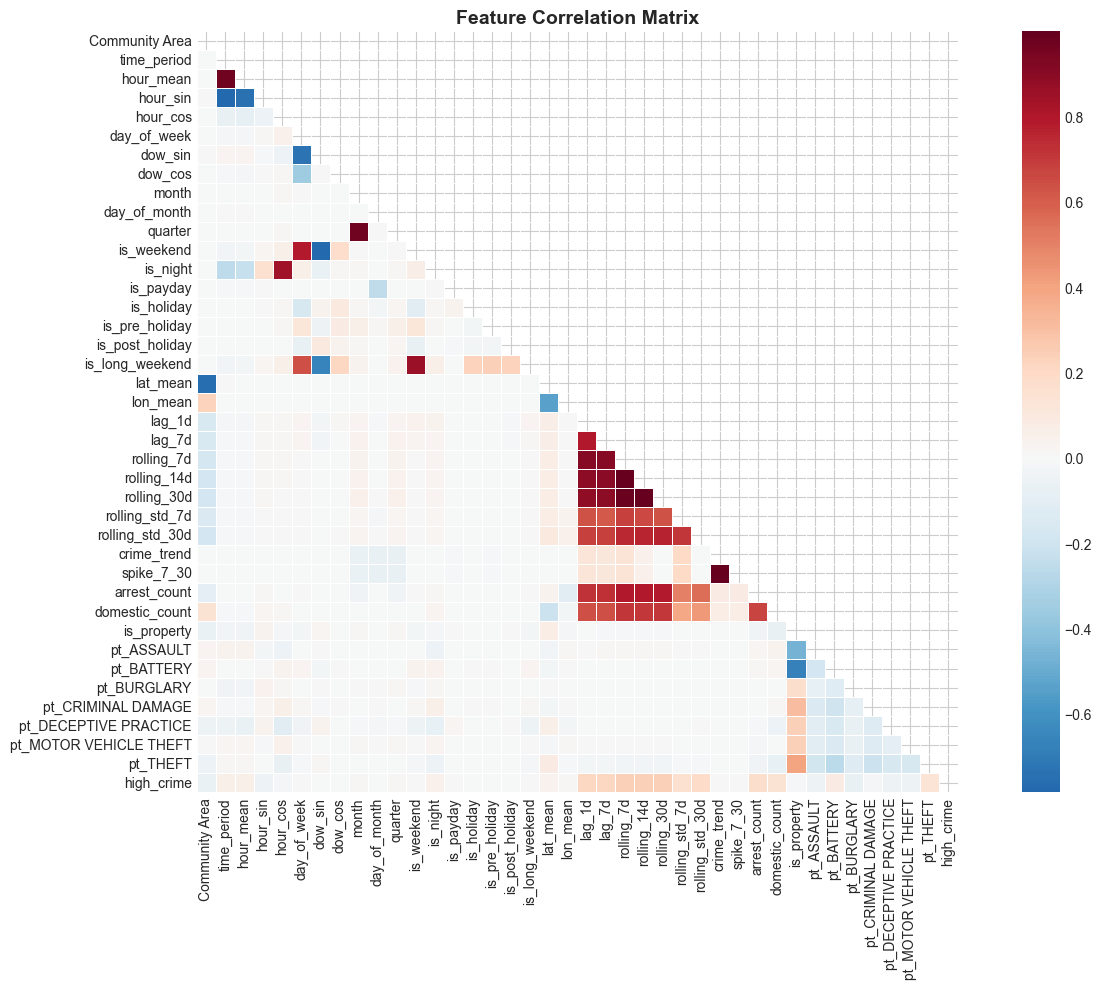

In [13]:
# Feature Correlation Heatmap + Feature List
model_df = agg_df[agg_df['crime_category'].isin(['PROPERTY', 'VIOLENT'])].copy()
model_df['is_property'] = (model_df['crime_category'] == 'PROPERTY').astype(int)

# One-hot encode top crime types retained from preprocessing
pt_dummies = pd.get_dummies(model_df['primary_type_topk'], prefix='pt', dtype=int)
if 'pt_OTHER' in pt_dummies.columns:
    pt_dummies = pt_dummies.drop(columns=['pt_OTHER'])
model_df = pd.concat([model_df, pt_dummies], axis=1)
pt_feature_cols = pt_dummies.columns.tolist()

FEATURE_COLS = [
    'Community Area', 'time_period',
    'hour_mean', 'hour_sin', 'hour_cos',
    'day_of_week', 'dow_sin', 'dow_cos',
    'month', 'day_of_month', 'quarter',
    'is_weekend', 'is_night', 'is_payday',
    'is_holiday', 'is_pre_holiday', 'is_post_holiday', 'is_long_weekend',
    'lat_mean', 'lon_mean',
    'lag_1d', 'lag_7d',
    'rolling_7d', 'rolling_14d', 'rolling_30d',
    'rolling_std_7d', 'rolling_std_30d',
    'crime_trend', 'spike_7_30',
    'arrest_count', 'domestic_count',
    'is_property'
] + pt_feature_cols

fig, ax = plt.subplots(figsize=(14, 10))
corr = model_df[FEATURE_COLS + ['high_crime']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


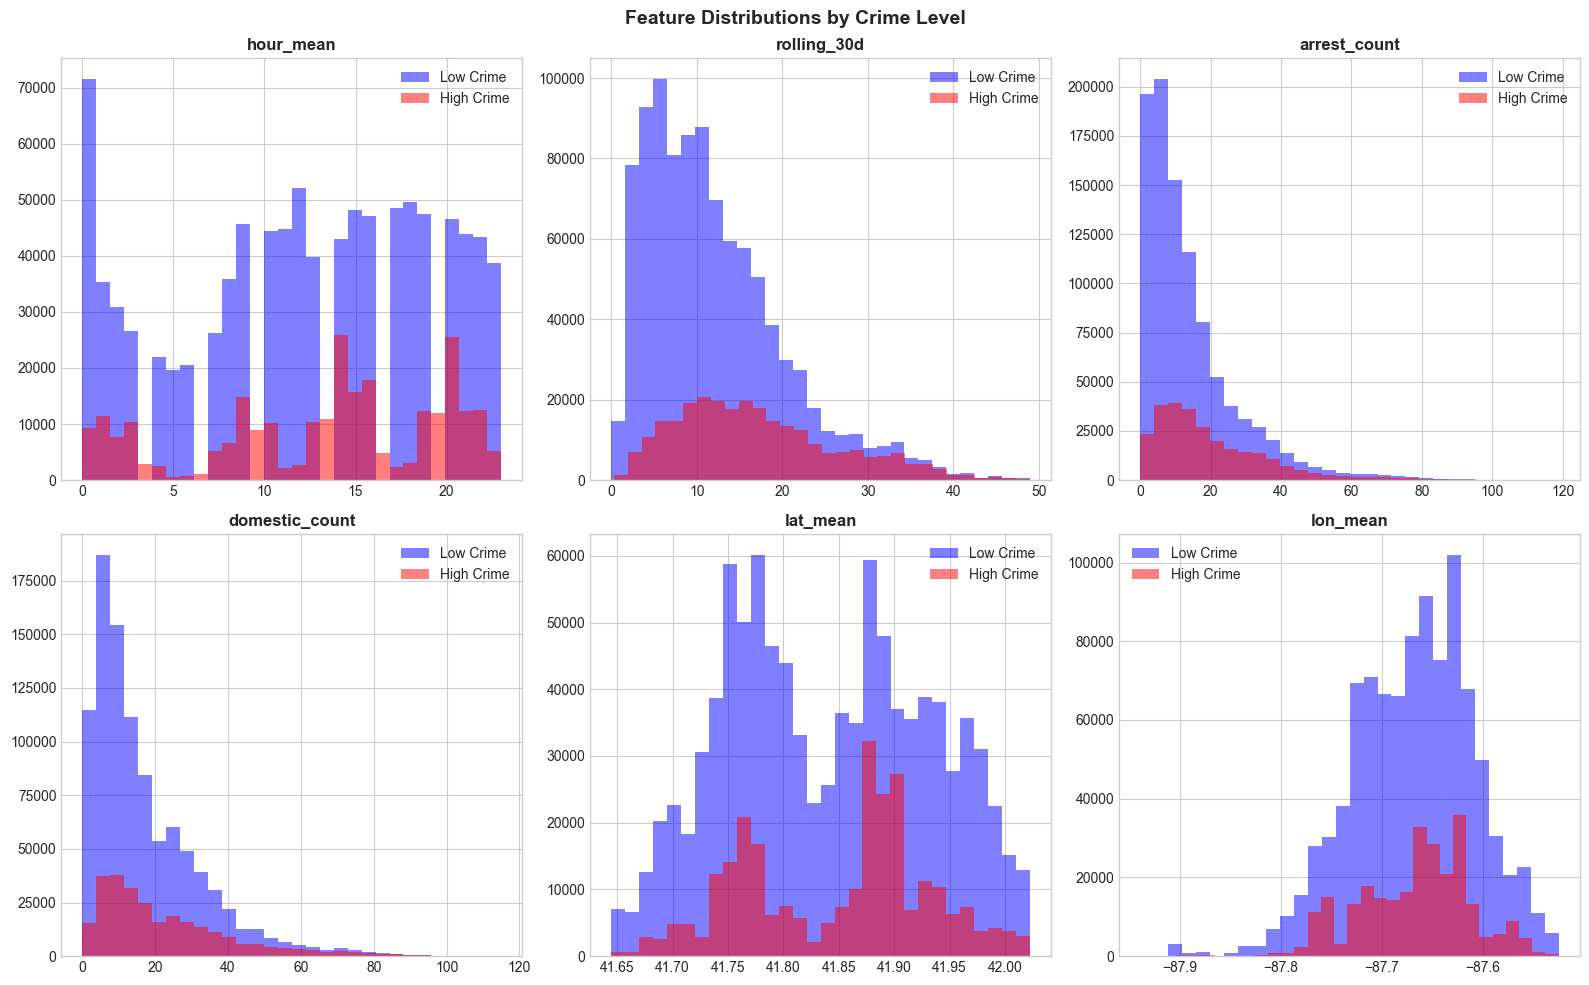

In [14]:
# Feature distributions by target class
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
features_to_plot = ['hour_mean', 'rolling_30d', 'arrest_count', 'domestic_count', 'lat_mean', 'lon_mean']
for i, feat in enumerate(features_to_plot):
    ax = axes[i//3, i%3]
    model_df[model_df['high_crime']==0][feat].hist(bins=30, alpha=0.5, label='Low Crime', ax=ax, color='blue')
    model_df[model_df['high_crime']==1][feat].hist(bins=30, alpha=0.5, label='High Crime', ax=ax, color='red')
    ax.set_title(f'{feat}', fontweight='bold')
    ax.legend()
plt.suptitle('Feature Distributions by Crime Level', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
import os
os.makedirs('data', exist_ok=True)

# Save the final engineered dataset for the modeling phase
model_df.to_csv('data/chicago_features_final.csv', index=False)
print("Feature engineering complete. Saved to data/chicago_features_final.csv (Shape: ", model_df.shape, ")")

Feature engineering complete. Saved to data/chicago_features_final.csv (Shape:  (1239581, 45) )


In [16]:
import os
import pandas as pd
import numpy as np

# ── Load Pre-engineered Features ──
# The raw data loading and feature engineering logic has been decoupled 
# into `ph3_feature_engineering.ipynb` to centralize data processing.
csv_path = 'data/chicago_features_final.csv'
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"{csv_path} missing. Please run ph3_feature_engineering.ipynb first.")

model_df = pd.read_csv(csv_path)

# Reconstruct FEATURE_COLS list
pt_feature_cols = [c for c in model_df.columns if c.startswith('pt_')]
FEATURE_COLS = [
    'Community Area', 'time_period',
    'hour_mean', 'hour_sin', 'hour_cos',
    'day_of_week', 'dow_sin', 'dow_cos',
    'month', 'day_of_month', 'quarter',
    'is_weekend', 'is_night', 'is_payday',
    'is_holiday', 'is_pre_holiday', 'is_post_holiday', 'is_long_weekend',
    'lat_mean', 'lon_mean',
    'lag_1d', 'lag_7d',
    'rolling_7d', 'rolling_14d', 'rolling_30d',
    'rolling_std_7d', 'rolling_std_30d',
    'crime_trend', 'spike_7_30',
    'arrest_count', 'domestic_count',
    'is_property'
] + pt_feature_cols

print(f"Loaded engineering dataset: {model_df.shape}")
print(f"Target distribution:\n{model_df['high_crime'].value_counts()}")

Loaded engineering dataset: (1239581, 45)
Target distribution:
high_crime
0    971626
1    267955
Name: count, dtype: int64


---
## 4. Model Training and Evaluation

### 4.1 Train/Test Split

We use a **chronological split**: 2018-2024 for training, 2025 for testing. This simulates real-world deployment where the model must predict future events.

In [17]:
# ── 4.1.1 Chronological Train/Test Split ──
train_mask = model_df['year'].astype(int) < 2025
test_mask = model_df['year'].astype(int) >= 2025

# Keep temporal order for time-aware validation
train_df_full = model_df.loc[train_mask].sort_values(['year', 'date_only']).copy()
test_df = model_df.loc[test_mask].copy()

train_df = train_df_full.copy()

In [18]:
from sklearn.model_selection import StratifiedKFold

# ── 4.1.2 Validation Sets & Time-Aware Cross Validation ──
# Independent threshold-tuning split (latest pre-test year)
all_train_years = sorted(train_df['year'].astype(int).unique())
threshold_year = all_train_years[-1]
threshold_df = train_df[train_df['year'].astype(int) == threshold_year].copy()
fit_df = train_df[train_df['year'].astype(int) < threshold_year].copy()

# Fallback if threshold-year split is degenerate
if len(fit_df) < 1000 or threshold_df['high_crime'].nunique() < 2:
    cutoff = int(len(train_df) * 0.85)
    fit_df = train_df.iloc[:cutoff].copy()
    threshold_df = train_df.iloc[cutoff:].copy()
    threshold_year = f"tail_split@{cutoff}"

# Build rolling/expanding year-based CV splits on fit set only
year_arr = fit_df['year'].astype(int).to_numpy()
years_sorted = sorted(fit_df['year'].astype(int).unique())
time_cv = []
time_cv_desc = []
for i in range(1, len(years_sorted)):
    train_years = years_sorted[:i]
    val_year = years_sorted[i]
    tr_idx = np.where(np.isin(year_arr, train_years))[0]
    va_idx = np.where(year_arr == val_year)[0]
    if len(tr_idx) > 0 and len(va_idx) > 0:
        time_cv.append((tr_idx, va_idx))
        time_cv_desc.append(f"train<= {max(train_years)} -> val={val_year}")

# Fallback: ensure at least 2 folds
if len(time_cv) < 2:
    from sklearn.model_selection import TimeSeriesSplit
    tscv = TimeSeriesSplit(n_splits=3)
    time_cv = list(tscv.split(fit_df))
    time_cv_desc = [f"TimeSeriesSplit fold {i+1}" for i in range(len(time_cv))]


skf = StratifiedKFold(n_splits=5, shuffle=False)
xgb_tune_cv = time_cv[:3] if len(time_cv) > 3 else time_cv


In [19]:
# ── 4.1.3 Feature Matrix Preparation & Collinearity Handling ──
# Collinearity handling using training-only statistics
corr_threshold = 0.95
fit_corr = fit_df[FEATURE_COLS].corr().abs()
upper = fit_corr.where(np.triu(np.ones(fit_corr.shape), k=1).astype(bool))
drop_cols = [col for col in upper.columns if any(upper[col] > corr_threshold)]
FEATURE_COLS_ORIG = FEATURE_COLS.copy()
FEATURE_COLS = [c for c in FEATURE_COLS if c not in drop_cols]

X_train = fit_df[FEATURE_COLS].values
y_train = fit_df['high_crime'].values
X_threshold = threshold_df[FEATURE_COLS].values
y_threshold = threshold_df['high_crime'].values
X_test = test_df[FEATURE_COLS].values
y_test = test_df['high_crime'].values

# Compute class weight ratio on fit set
pos_rate_train = y_train.mean()
neg_rate_train = 1 - pos_rate_train
scale_pos_weight = neg_rate_train / max(pos_rate_train, 1e-8)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_threshold_scaled = scaler.transform(X_threshold)
X_test_scaled = scaler.transform(X_test)

print(f"Train-fit set:      {X_train.shape}")
print(f"Threshold set:      {X_threshold.shape} (year={threshold_year})")
print(f"Test set:           {X_test.shape}")
print()
print(f"Time CV folds ({len(time_cv)}):")
for d in time_cv_desc:
    print(f"  - {d}")


Train-fit set:      (921044, 34)
Threshold set:      (166924, 34) (year=2024)
Test set:           (151613, 34)

Time CV folds (5):
  - train<= 2018 -> val=2019
  - train<= 2019 -> val=2020
  - train<= 2020 -> val=2021
  - train<= 2021 -> val=2022
  - train<= 2022 -> val=2023


### 4.2 Model 1: Logistic Regression (Baseline)

Logistic Regression serves as our interpretable baseline model. It provides a performance floor against which more complex models are compared.

In [20]:
# Logistic Regression with Hyperparameter Tuning
from sklearn.pipeline import Pipeline

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        penalty='l2',
        solver='saga',
        max_iter=500,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

lr_param_grid = {'clf__C': [0.01, 0.1, 1.0, 10.0]}
lr_grid = GridSearchCV(lr_pipe, lr_param_grid, cv=time_cv, scoring='f1', n_jobs=-1, verbose=0)
lr_grid.fit(X_train, y_train)
print(f"LR Best Parameters: {lr_grid.best_params_}")
print(f"LR Best CV F1: {lr_grid.best_score_:.4f}")

lr = lr_grid.best_estimator_

# Cross-validation on best estimator
lr_cv = cross_val_score(lr, X_train, y_train, cv=skf, scoring='f1', n_jobs=-1)
print(f"\nLogistic Regression - 5-Fold CV F1: {lr_cv.mean():.4f} (+/- {lr_cv.std():.4f})")
print(f"  Fold scores: {[f'{s:.4f}' for s in lr_cv]}")

# Test set evaluation
# Tune threshold on independent threshold set
lr_prob_thr = lr.predict_proba(X_threshold)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_threshold, lr_prob_thr)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
lr_best_threshold = float(thresholds[best_idx]) if best_idx < len(thresholds) else 0.5
print(f"LR Selected threshold: {lr_best_threshold:.4f}")

# Apply tuned threshold for testing
lr_prob = lr.predict_proba(X_test)[:, 1]
lr_pred = (lr_prob >= lr_best_threshold).astype(int)


print(f"\nTest Set Performance:")
print(f"  Accuracy:  {accuracy_score(y_test, lr_pred):.4f}")
print(f"  Precision: {precision_score(y_test, lr_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, lr_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, lr_pred):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, lr_prob):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=['Low Crime', 'High Crime']))


LR Best Parameters: {'clf__C': 0.01}
LR Best CV F1: 0.4581

Logistic Regression - 5-Fold CV F1: 0.4668 (+/- 0.0154)
  Fold scores: ['0.4814', '0.4883', '0.4545', '0.4609', '0.4487']
LR Selected threshold: 0.5494

Test Set Performance:
  Accuracy:  0.7268
  Precision: 0.3966
  Recall:    0.5719
  F1-Score:  0.4684
  AUC-ROC:   0.7364

Classification Report:
              precision    recall  f1-score   support

   Low Crime       0.87      0.77      0.82    119707
  High Crime       0.40      0.57      0.47     31906

    accuracy                           0.73    151613
   macro avg       0.63      0.67      0.64    151613
weighted avg       0.77      0.73      0.74    151613



### 4.3 Model 2: Random Forest

Random Forest captures non-linear feature interactions through an ensemble of decision trees, making it well-suited for spatial hotspot identification.

In [ ]:
# Random Forest
rf = RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE)

# Random Search for best hyperparameters (time-aware, as requested)
rf_param_grid = {
    'max_depth': [10, 20, 30, 40],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2'],
    'n_estimators': [200]
}

rf_random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=time_cv,
    scoring='f1',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf_random_search.fit(X_train, y_train)

print(f"Best Parameters: {rf_random_search.best_params_}")
print(f"Best CV F1: {rf_random_search.best_score_:.4f}")

# Cross-validation
rf_best = rf_random_search.best_estimator_
rf_cv = cross_val_score(rf_best, X_train, y_train, cv=time_cv, scoring='f1', n_jobs=-1)
print(f"Random Forest - Time CV F1: {rf_cv.mean():.4f} (+/- {rf_cv.std():.4f})")
print(f"  Fold scores: {[f'{s:.4f}' for s in rf_cv]}")

# Test set evaluation
# Tune threshold on independent threshold set
rf_prob_thr = rf_best.predict_proba(X_threshold)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_threshold, rf_prob_thr)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
rf_best_threshold = float(thresholds[best_idx]) if best_idx < len(thresholds) else 0.5
print(f"RF Selected threshold: {rf_best_threshold:.4f}")

# Apply tuned threshold for testing
rf_prob = rf_best.predict_proba(X_test)[:, 1]
rf_pred = (rf_prob >= rf_best_threshold).astype(int)


print(f"\nTest Set Performance:")
print(f"  Accuracy:  {accuracy_score(y_test, rf_pred):.4f}")
print(f"  Precision: {precision_score(y_test, rf_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, rf_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, rf_pred):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, rf_prob):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Low Crime', 'High Crime']))


Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 40}
Best CV F1: 0.8662
Random Forest - Time CV F1: 0.8662 (+/- 0.0138)
  Fold scores: ['0.8453', '0.8560', '0.8701', '0.8763', '0.8832']
RF Selected threshold: 0.3881

Test Set Performance:
  Accuracy:  0.9613
  Precision: 0.9794
  Recall:    0.8334
  F1-Score:  0.9005
  AUC-ROC:   0.9423

Classification Report:
              precision    recall  f1-score   support

   Low Crime       0.96      1.00      0.98    119707
  High Crime       0.98      0.83      0.90     31906

    accuracy                           0.96    151613
   macro avg       0.97      0.91      0.94    151613
weighted avg       0.96      0.96      0.96    151613



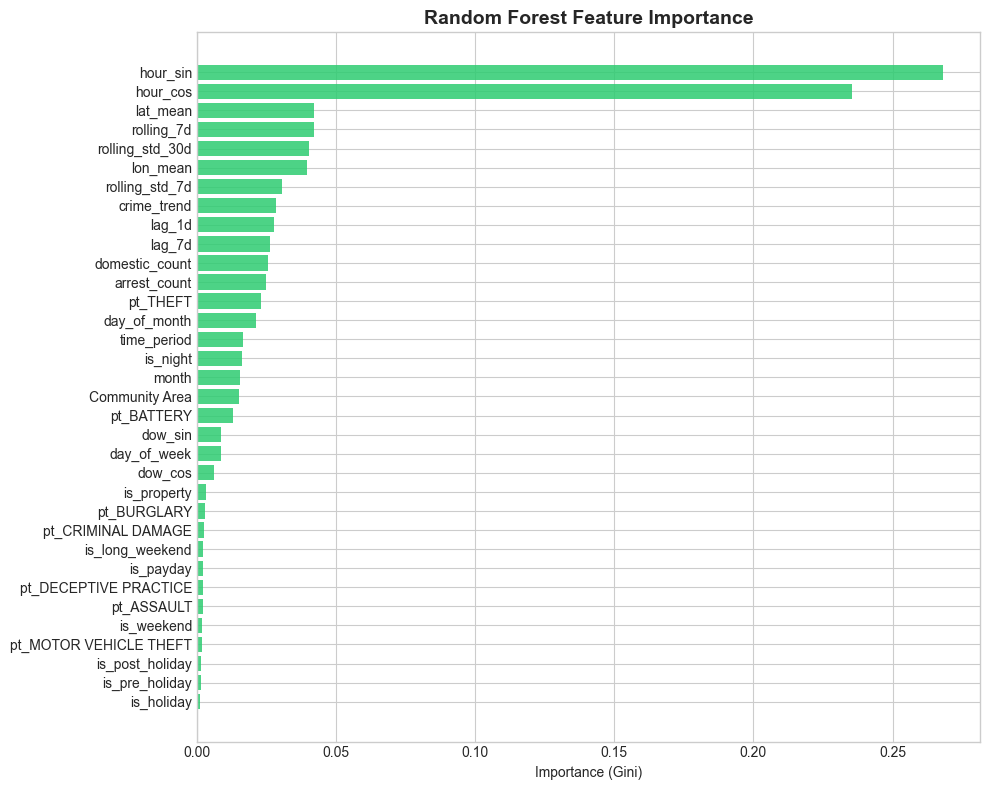

Top 5 Features:
  hour_sin             0.2680
  hour_cos             0.2354
  lat_mean             0.0422
  rolling_7d           0.0420
  rolling_std_30d      0.0403


In [22]:
# Random Forest Feature Importance
rf_importance = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': rf_best.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(rf_importance['Feature'], rf_importance['Importance'], color='#2ecc71', alpha=0.85)
ax.set_xlabel('Importance (Gini)')
ax.set_title('Random Forest Feature Importance', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("Top 5 Features:")
for _, row in rf_importance.tail(5).iloc[::-1].iterrows():
    print(f"  {row['Feature']:<20s} {row['Importance']:.4f}")


### 4.4 Model 3: XGBoost (Primary Model)

XGBoost is our primary classification model. We perform hyperparameter tuning using RandomizedSearchCV to find the optimal configuration.

In [23]:
# XGBoost with Time-Aware Hyperparameter Tuning
neg = float((y_train == 0).sum())
pos = float((y_train == 1).sum())
base_spw = (neg / max(pos, 1.0)) if pos > 0 else 1.0
spw_candidates = sorted(set([
    max(1.0, round(base_spw * 0.5, 2)),
    max(1.0, round(base_spw * 0.8, 2)),
    max(1.0, round(base_spw, 2)),
    max(1.0, round(base_spw * 1.2, 2)),
]))
print(f"Training class balance: neg={int(neg):,}, pos={int(pos):,}, base_scale_pos_weight={base_spw:.3f}")
print(f"scale_pos_weight candidates: {spw_candidates}")

xgb_base = xgb.XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    n_jobs=-1,
)

param_dist = {
    'n_estimators': [300, 500, 800],
    'max_depth': [4, 5, 6, 7, 8],
    'learning_rate': [0.03, 0.05, 0.08],
    'min_child_weight': [5, 8, 10, 12],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'gamma': [0.0, 0.1, 0.3, 0.5, 1.0],
    'reg_alpha': [0.0, 0.05, 0.1, 0.3, 0.5],
    'reg_lambda': [0.5, 1.0, 2.0, 5.0, 10.0],
    'scale_pos_weight': spw_candidates,
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,
    cv=xgb_tune_cv,
    scoring='f1',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)

xgb_search.fit(X_train, y_train)
print(f"Best Parameters: {xgb_search.best_params_}")
print(f"Best CV F1: {xgb_search.best_score_:.4f}")

xgb_best = xgb_search.best_estimator_
xgb_cv = cross_val_score(xgb_best, X_train, y_train, cv=time_cv, scoring='f1', n_jobs=-1)
print()
print(f"XGBoost - Time CV F1: {xgb_cv.mean():.4f} (+/- {xgb_cv.std():.4f})")
print(f"  Fold scores: {[f'{s:.4f}' for s in xgb_cv]}")

# Threshold optimization on independent threshold set
xgb_thr_prob = xgb_best.predict_proba(X_threshold)[:, 1]
prec, rec, thr = precision_recall_curve(y_threshold, xgb_thr_prob)
if len(thr) > 0:
    f1_curve = 2 * prec[:-1] * rec[:-1] / np.clip(prec[:-1] + rec[:-1], 1e-12, None)
    best_idx = int(np.nanargmax(f1_curve))
    xgb_best_threshold = float(thr[best_idx])
    thr_f1 = float(f1_curve[best_idx])
else:
    xgb_best_threshold = 0.5
    thr_f1 = np.nan

xgb_prob = xgb_best.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_prob >= xgb_best_threshold).astype(int)

print()
print(f"Selected threshold on threshold-set: {xgb_best_threshold:.4f} (best F1={thr_f1:.4f})")
print()
print("Test Set Performance:")
print(f"  Accuracy:  {accuracy_score(y_test, xgb_pred):.4f}")
print(f"  Precision: {precision_score(y_test, xgb_pred, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, xgb_pred, zero_division=0):.4f}")
print(f"  F1-Score:  {f1_score(y_test, xgb_pred, zero_division=0):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, xgb_prob):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, xgb_pred, target_names=['Low Crime', 'High Crime']))


Training class balance: neg=722,511, pos=198,533, base_scale_pos_weight=3.639
scale_pos_weight candidates: [1.82, 2.91, 3.64, 4.37]
Best Parameters: {'subsample': 0.9, 'scale_pos_weight': 1.82, 'reg_lambda': 10.0, 'reg_alpha': 0.5, 'n_estimators': 500, 'min_child_weight': 8, 'max_depth': 5, 'learning_rate': 0.08, 'gamma': 0.0, 'colsample_bytree': 0.6}
Best CV F1: 0.9107

XGBoost - Time CV F1: 0.9088 (+/- 0.0036)
  Fold scores: ['0.9150', '0.9106', '0.9063', '0.9053', '0.9066']

Selected threshold on threshold-set: 0.4634 (best F1=0.9114)

Test Set Performance:
  Accuracy:  0.9657
  Precision: 0.9965
  Recall:    0.8399
  F1-Score:  0.9115
  AUC-ROC:   0.9548

Classification Report:
              precision    recall  f1-score   support

   Low Crime       0.96      1.00      0.98    119707
  High Crime       1.00      0.84      0.91     31906

    accuracy                           0.97    151613
   macro avg       0.98      0.92      0.95    151613
weighted avg       0.97      0.97    

### 4.5 Model 4: LSTM (Time-Series Model)

In [24]:
# LSTM Data Preparation & Model Training

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, LearningRateScheduler
from tensorflow.keras.regularizers import l2
import numpy as np
import pandas as pd

# 1. Prepare daily time-series per community area using the selected 19 daily features
agg_dict = {
    'crime_count': ('crime_count', 'sum'),
    'high_crime': ('high_crime', 'max'),
    'year': ('year', 'first')
}

sum_cols = ['arrest_count', 'domestic_count']
mean_cols = ['lag_1d', 'lag_7d', 'rolling_7d', 'rolling_std_7d', 'rolling_std_30d', 'crime_trend']
calendar_cols = [
    'is_weekend', 'is_payday', 'is_holiday',
    'is_pre_holiday', 'is_post_holiday', 'is_long_weekend',
    'month', 'day_of_month'
]

for col in sum_cols:
    if col in model_df.columns:
        agg_dict[col] = (col, 'sum')
for col in mean_cols:
    if col in model_df.columns:
        agg_dict[col] = (col, 'mean')
for col in calendar_cols:
    if col in model_df.columns:
        agg_dict[col] = (col, 'first')

ts_daily = model_df.groupby(['Community Area', 'date_only']).agg(**agg_dict).reset_index()

# Add cyclical day-of-week encoding
# Keep day-level temporal context inside each 14-day sequence.
ts_daily['date_only'] = pd.to_datetime(ts_daily['date_only'])
ts_daily['dow'] = ts_daily['date_only'].dt.dayofweek
ts_daily['dow_sin'] = np.sin(2 * np.pi * ts_daily['dow'] / 7)
ts_daily['dow_cos'] = np.cos(2 * np.pi * ts_daily['dow'] / 7)

# 2. Setup the 19-feature LSTM input set
SEQ_LEN = 14
LSTM_FEATURES = [
    'crime_count',
    'lag_1d', 'lag_7d',
    'rolling_7d', 'rolling_std_7d', 'rolling_std_30d', 'crime_trend',
    'arrest_count', 'domestic_count',
    'dow_sin', 'dow_cos',
    'month', 'day_of_month',
    'is_weekend', 'is_payday',
    'is_holiday', 'is_pre_holiday', 'is_post_holiday', 'is_long_weekend'
]
LSTM_FEATURES = [f for f in LSTM_FEATURES if f in ts_daily.columns]

all_areas = ts_daily['Community Area'].unique()
print(f"Building {SEQ_LEN}-day sequences for {len(all_areas)} community areas...")
print(f"LSTM Features selected ({len(LSTM_FEATURES)} total): {LSTM_FEATURES}")

sequences, labels, seq_years, seq_ca, seq_date = [], [], [], [], []
for ca in all_areas:
    ca_data = ts_daily[ts_daily['Community Area'] == ca].sort_values('date_only').copy()
    if len(ca_data) < SEQ_LEN + 1:
        continue

    feat_vals = ca_data[LSTM_FEATURES].values.astype(float)
    tgts = ca_data['high_crime'].values
    yrs = ca_data['year'].values
    dates = ca_data['date_only'].values

    # Normalize using fit-period statistics only (2018-2023) to keep
    # validation (2024) and test (2025) fully held out.
    fit_portion = ca_data['year'].astype(int) < 2024
    fit_feat = feat_vals[fit_portion.values]
    if len(fit_feat) < SEQ_LEN:
        continue
    feat_mean = fit_feat.mean(axis=0)
    feat_std = fit_feat.std(axis=0) + 1e-8
    feat_vals = (feat_vals - feat_mean) / feat_std

    for i in range(SEQ_LEN, len(feat_vals)):
        sequences.append(feat_vals[i - SEQ_LEN:i])
        labels.append(tgts[i])
        seq_years.append(yrs[i])
        seq_ca.append(ca)
        seq_date.append(dates[i])

X_seq = np.array(sequences)
y_seq = np.array(labels)
seq_years = np.array(seq_years).astype(int)
seq_ca = np.array(seq_ca)
seq_date = np.array(seq_date)

lstm_fit_mask = seq_years < 2024
lstm_val_mask = seq_years == 2024
lstm_test_mask = seq_years >= 2025

X_tr_chi, X_val_chi, X_te_chi = X_seq[lstm_fit_mask], X_seq[lstm_val_mask], X_seq[lstm_test_mask]
y_tr_chi, y_val_chi, y_te_chi = y_seq[lstm_fit_mask], y_seq[lstm_val_mask], y_seq[lstm_test_mask]
ca_te_chi, date_te_chi = seq_ca[lstm_test_mask], seq_date[lstm_test_mask]

if len(X_tr_chi) == 0 or len(X_val_chi) == 0 or len(X_te_chi) == 0:
    raise RuntimeError('LSTM split is empty. Check yearly sequence coverage before training.')

pos_weight = (y_tr_chi == 0).sum() / max((y_tr_chi == 1).sum(), 1)
print(
    f"\nLSTM Fit Samples: {X_tr_chi.shape[0]:,}  |  "
    f"Validation Samples: {X_val_chi.shape[0]:,}  |  Test Samples: {X_te_chi.shape[0]:,}"
)
print(f"Sequence shape: {X_seq.shape}")
print(
    f"Positive rate -> fit: {y_tr_chi.mean():.2%}, "
    f"val: {y_val_chi.mean():.2%}, test: {y_te_chi.mean():.2%}"
)

# 3. Model Architecture (Archive V2.0)
def build_optimized_lstm(seq_len, n_features, lstm_units=(64, 32), lr=5e-4, l2_reg=1e-4):
    model = Sequential([
        LSTM(lstm_units[0], return_sequences=True,
             kernel_regularizer=l2(l2_reg), recurrent_regularizer=l2(l2_reg),
             input_shape=(seq_len, n_features)),
        BatchNormalization(),
        Dropout(0.35),
        LSTM(lstm_units[1], kernel_regularizer=l2(l2_reg), recurrent_regularizer=l2(l2_reg)),
        BatchNormalization(),
        Dropout(0.25),
        Dense(16, activation='relu', kernel_regularizer=l2(l2_reg)),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    optimizer = tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=l2_reg, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

lstm_model = build_optimized_lstm(SEQ_LEN, len(LSTM_FEATURES))
lstm_model.summary()

def cosine_annealing(epoch, lr, total_epochs=30, min_lr=1e-6):
    import numpy as np
    return min_lr + 0.5 * (5e-4 - min_lr) * (1 + np.cos(np.pi * epoch / total_epochs))

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    # ReduceLROnPlateau(patience=3, factor=0.5, min_lr=1e-6),
    LearningRateScheduler(cosine_annealing)
]

history = lstm_model.fit(
    X_tr_chi, y_tr_chi, epochs=30, batch_size=128,
    validation_data=(X_val_chi, y_val_chi),
    class_weight={0: 1.0, 1: pos_weight},
    callbacks=callbacks, verbose=1
)




Building 14-day sequences for 77 community areas...
LSTM Features selected (19 total): ['crime_count', 'lag_1d', 'lag_7d', 'rolling_7d', 'rolling_std_7d', 'rolling_std_30d', 'crime_trend', 'arrest_count', 'domestic_count', 'dow_sin', 'dow_cos', 'month', 'day_of_month', 'is_weekend', 'is_payday', 'is_holiday', 'is_pre_holiday', 'is_post_holiday', 'is_long_weekend']

LSTM Fit Samples: 156,904  |  Validation Samples: 26,710  |  Test Samples: 26,369
Sequence shape: (209983, 14, 19)
Positive rate -> fit: 52.43%, val: 56.40%, test: 52.49%


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 14, 64)         │        21,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,849 (136.13 KB)

 Trainable params: 34,657 (135.38 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/30
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.5920 - loss: 0.6627 - val_accuracy: 0.6782 - val_loss: 0.6178 - learning_rate: 5.0000e-04
Epoch 2/30
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6921 - loss: 0.5742 - val_accuracy: 0.7209 - val_loss: 0.5685 - learning_rate: 4.9863e-04
Epoch 3/30
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.7211 - loss: 0.5427 - val_accuracy: 0.7292 - val_loss: 0.5546 - learning_rate: 4.9455e-04
Epoch 4/30
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7282 - loss: 0.5313 - val_accuracy: 0.7314 - val_loss: 0.5490 - learning_rate: 4.8779e-04
Epoch 5/30
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7343 - loss: 0.5236 - val_accuracy: 0.7354 - val_loss: 0.5436 - learning_rate: 4.7843e-04
Epoch 6/30
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.7365 - loss: 0.5187 - val_accuracy: 0.7388 - val_loss: 0.5412 - learning_rate: 4.6657e-04
Epoch 7/30
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 10s 

825/825 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
LSTM Test Set Performance:
  Accuracy:  0.7207
  Precision: 0.7385
  Recall:    0.7241
  F1-Score:  0.7313
  AUC-ROC:   0.7938
Classification Report:
              precision    recall  f1-score   support

   Low Crime       0.70      0.72      0.71     12529
  High Crime       0.74      0.72      0.73     13840

    accuracy                           0.72     26369
   macro avg       0.72      0.72      0.72     26369
weighted avg       0.72      0.72      0.72     26369



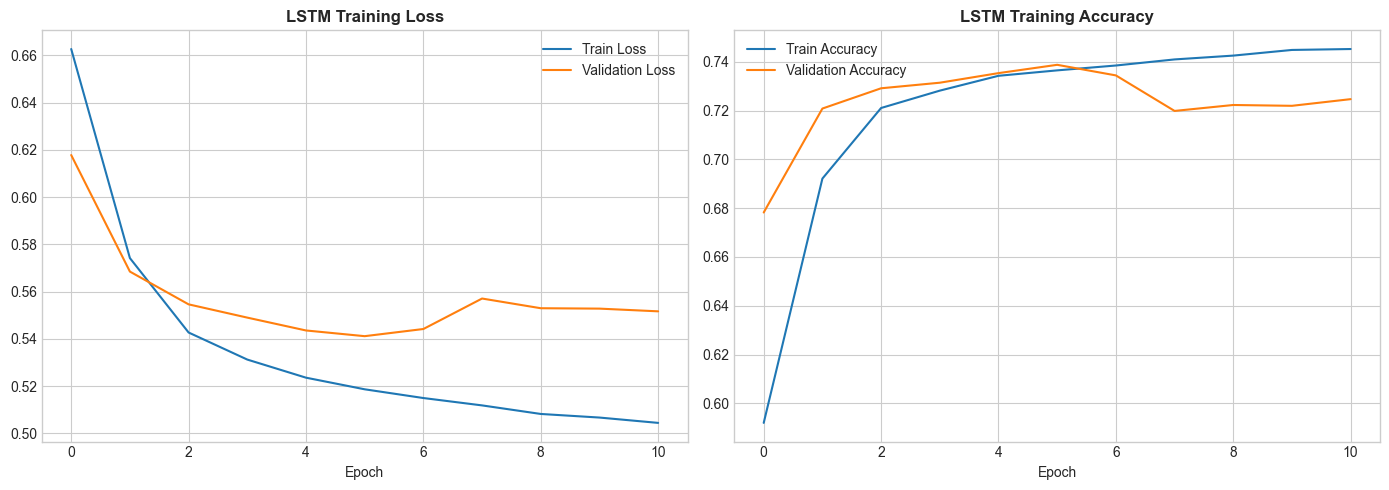

In [25]:
# LSTM Evaluation & Plotting

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

lstm_prob = lstm_model.predict(X_te_chi).flatten()
lstm_pred = (lstm_prob > 0.5).astype(int)

print(f"LSTM Test Set Performance:")
print(f"  Accuracy:  {accuracy_score(y_te_chi, lstm_pred):.4f}")
print(f"  Precision: {precision_score(y_te_chi, lstm_pred, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_te_chi, lstm_pred, zero_division=0):.4f}")
print(f"  F1-Score:  {f1_score(y_te_chi, lstm_pred, zero_division=0):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_te_chi, lstm_prob):.4f}")
print(f"Classification Report:")
print(classification_report(y_te_chi, lstm_pred, target_names=['Low Crime', 'High Crime'], zero_division=0))

# Aggregate predictions to community-area level for hotspot comparison
lstm_test_df = pd.DataFrame({
    'community_area': ca_te_chi,
    'date_only': date_te_chi,
    'prob': lstm_prob,
    'target': y_te_chi
})

lstm_ca_prob = lstm_test_df.groupby('community_area')['prob'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('LSTM Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('LSTM Training Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.show()


---
## Evaluation Protocol and Evidence Tiers

This notebook separates evidence into four tiers so that the final report does not mix official claims, supporting diagnostics, exploratory probes, and appendix-only artifacts.

### Tier 1 — Official Main Results
- **Chicago main results**: 2025 holdout evaluation for the tabular models (row-level protocol).
- **Chicago LSTM**: sequence-based 2025 subset reported as a **secondary official track**, not as a row-level equivalent to the tabular models.
- **NIBRS external validation**: strict zero-shot evaluation using the locked Chicago thresholds.

### Tier 2 — Supporting Diagnostics
- SHAP analysis and feature-stability analysis.
- Chicago vs NIBRS SHAP comparison.
- Monthly trend / drift monitoring.
- Calibration analysis and cross-domain error slices.

### Tier 3 — Exploratory Probe
- The chronological 20% adaptation probe is used only to assess **localization potential**.
- It does **not** replace the strict zero-shot external-validation results.

### Tier 4 — Appendix / Operational Notes
- Model persistence, saved artifacts, rerun notes, and implementation details.
- These cells support reproducibility but are not part of the main performance claims.

Only Tier-1 results should be cited as the official headline findings. Tier-2 explains why the results behave as they do. Tier-3 is exploratory. Tier-4 is operational.


---
## 5. Chicago Main Results [Official]

### 5.1 Scope and reporting note

This section consolidates the official Chicago evaluation outputs.

- **Tabular models** are evaluated on the 2025 row-level holdout.
- **LSTM** is evaluated on a sequence-derived 2025 subset and should be interpreted as a **secondary official track** rather than a row-level equivalent to the tabular models.
- The comparison plots below are useful for headline comparison, but they do not imply identical sample construction across all four models.

### 5.2 Official comparison snapshot



In [26]:
# Model Comparison Table (dynamically computed)
# This cell can be executed even if some models (RF/XGBoost/LSTM) were not trained in this session.
candidates = [
    ('Logistic Regression', 'lr_pred', 'lr_prob', 'y_test', 'lr_cv'),
    ('Random Forest',       'rf_pred', 'rf_prob', 'y_test', 'rf_cv'),
    ('XGBoost',             'xgb_pred', 'xgb_prob', 'y_test', 'xgb_cv'),
    ('LSTM',                'lstm_pred', 'lstm_prob', 'y_te_chi', 'lstm_cv_scores'),
]

model_metrics = {}
missing_models = []

for name, pred_var, prob_var, true_var, cv_var in candidates:
    if any(var_name not in globals() for var_name in [pred_var, prob_var, true_var]):
        missing_models.append(name)
        continue

    pred = globals()[pred_var]
    prob = globals()[prob_var]
    true = globals()[true_var]
    cv_scores = globals().get(cv_var, None) if cv_var is not None else None

    # Special-case: LSTM time-series CV scores (rolling window) are computed separately.
    if name == 'LSTM' and 'lstm_cv_scores' in globals() and len(lstm_cv_scores) > 0:
        cv_scores = np.array(lstm_cv_scores)

    model_metrics[name] = {
        'Accuracy':  accuracy_score(true, pred),
        'Precision': precision_score(true, pred),
        'Recall':    recall_score(true, pred),
        'F1-Score':  f1_score(true, pred),
        'AUC-ROC':   roc_auc_score(true, prob),
    }
    if cv_scores is not None and len(cv_scores) > 0:
        model_metrics[name]['CV F1 Mean'] = cv_scores.mean()
        model_metrics[name]['CV F1 Std']  = cv_scores.std()

if missing_models:
    print(" Skipped model comparison for the following models (not trained / missing variables):")
    for m in missing_models:
        print(f"  - {m}")
    print("")

if not model_metrics:
    raise RuntimeError("No trained model outputs are available for comparison. Please run the model training cells first.")

results = pd.DataFrame(model_metrics).T

print("=" * 90)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 90)
print(results.round(4).to_string())
print("\n" + "=" * 90)
best_model_name = results['AUC-ROC'].idxmax()
best_auc = results['AUC-ROC'].max()
best_f1 = results.loc[best_model_name, 'F1-Score']
print(f"BEST MODEL: {best_model_name} (AUC-ROC = {best_auc:.3f}, F1 = {best_f1:.3f})")
print("=" * 90)

MODEL PERFORMANCE COMPARISON
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC  CV F1 Mean  CV F1 Std
Logistic Regression    0.7268     0.3966  0.5719    0.4684   0.7364      0.4668     0.0154
Random Forest          0.9613     0.9794  0.8334    0.9005   0.9423      0.8662     0.0138
XGBoost                0.9657     0.9965  0.8399    0.9115   0.9548      0.9088     0.0036
LSTM                   0.7207     0.7385  0.7241    0.7313   0.7938         NaN        NaN

BEST MODEL: XGBoost (AUC-ROC = 0.955, F1 = 0.912)


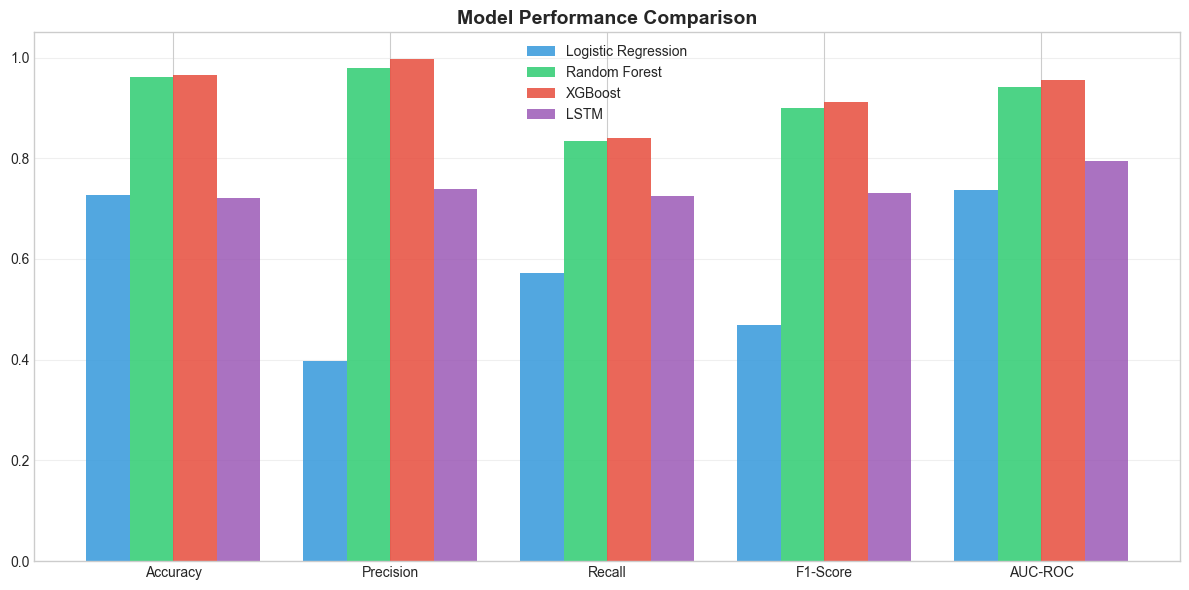

In [27]:
# Model Performance Comparison Chart
fig, ax = plt.subplots(figsize=(12, 6))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metrics_to_plot))
width = 0.2
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for i, (model_name, color) in enumerate(zip(results.index, colors)):
    values = [results.loc[model_name, m] for m in metrics_to_plot]
    ax.bar(x + i * width, values, width, label=model_name, color=color, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.05)
ax.legend()
ax.set_title('Model Performance Comparison', fontweight='bold', fontsize=14)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

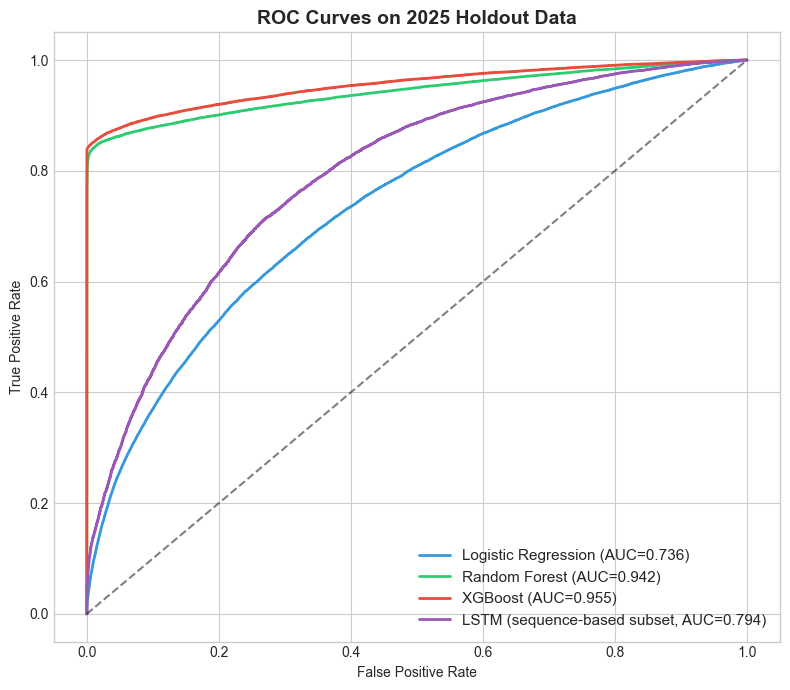

In [28]:
# ROC Curves - All models on same plot
fig, ax = plt.subplots(figsize=(8, 7))

colors = {'Logistic Regression': '#3498db', 'Random Forest': '#2ecc71',
          'XGBoost': '#e74c3c', 'LSTM': '#9b59b6'}

for name, prob, true in [('Logistic Regression', lr_prob, y_test),
                          ('Random Forest', rf_prob, y_test),
                          ('XGBoost', xgb_prob, y_test),
                          ('LSTM', lstm_prob, y_te_chi)]:
    fpr, tpr, _ = roc_curve(true, prob)
    auc = roc_auc_score(true, prob)
    label = f'{name} (AUC={auc:.3f})'
    if name == 'LSTM':
        label = f'{name} (sequence-based subset, AUC={auc:.3f})'
    ax.plot(fpr, tpr, color=colors[name], label=label, linewidth=2)

ax.plot([0,1], [0,1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves on 2025 Holdout Data', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()



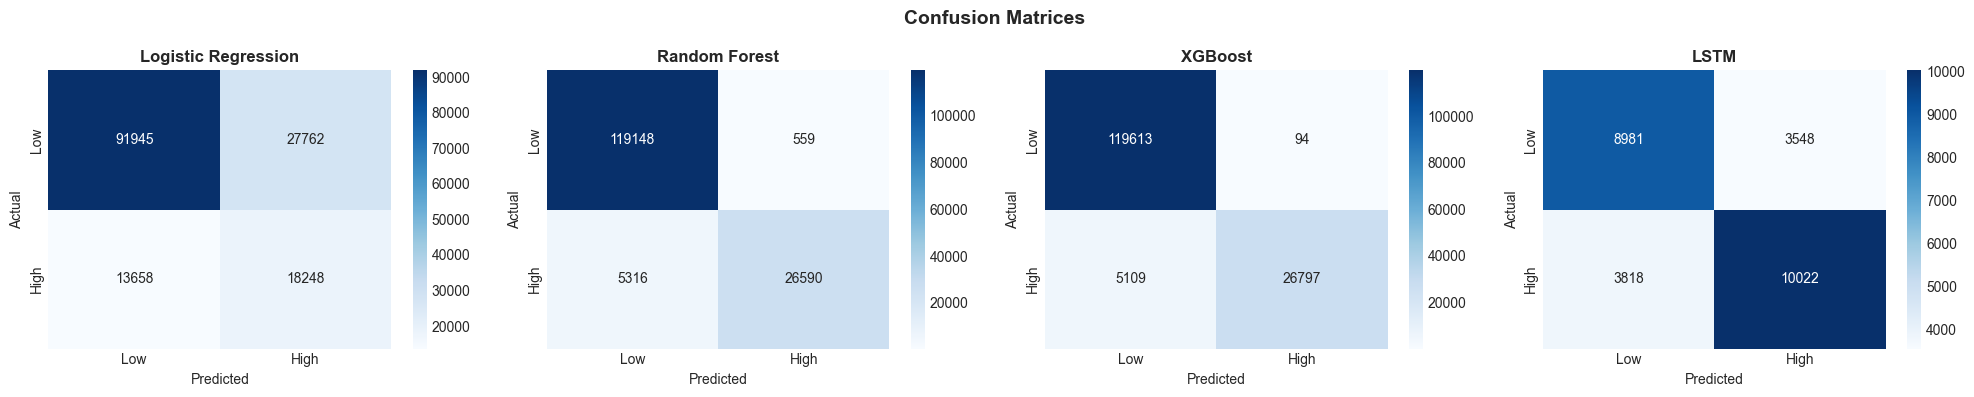

In [29]:
# Confusion Matrices
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
models_data = [
    ('Logistic Regression', lr_pred, y_test),
    ('Random Forest', rf_pred, y_test),
    ('XGBoost', xgb_pred, y_test),
    ('LSTM', lstm_pred, y_te_chi)
]

for ax, (name, pred, true) in zip(axes, models_data):
    cm = confusion_matrix(true, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
# Spatial Accuracy: Hotspot Hit Rate
# Compare top 10 predicted vs actual highest-risk community areas
# Note: our cleaned dataset uses 'Community Area' (title case) as the column name.
test_eval = model_df[model_df['year'].astype(int) >= 2025].copy()
# Ensure a consistent column for grouping
test_eval['community_area'] = test_eval['Community Area']
actual_hotspots = test_eval.groupby('community_area')['high_crime'].mean()
top_actual = set(actual_hotspots.nlargest(10).index)

test_eval['lr_prob'] = lr_prob
test_eval['rf_prob'] = rf_prob
test_eval['xgb_prob'] = xgb_prob

print("Spatial Accuracy - Hotspot Hit Rate (Top 10 Areas)")
print("=" * 50)
for name, prob_col in [('Logistic Regression', 'lr_prob'), 
                        ('Random Forest', 'rf_prob'), 
                        ('XGBoost', 'xgb_prob'),
                        ('LSTM', None)]:
    if name == 'LSTM':
        pred_hotspots = lstm_ca_prob
    else:
        pred_hotspots = test_eval.groupby('community_area')[prob_col].mean()

    top_pred = set(pred_hotspots.nlargest(10).index)
    hit_rate = len(top_actual & top_pred) / len(top_actual)
    print(f"  {name:<25s} Hit Rate: {hit_rate:.0%}  ({len(top_actual & top_pred)}/10 areas)")
print("=" * 50)

Spatial Accuracy - Hotspot Hit Rate (Top 10 Areas)
  Logistic Regression       Hit Rate: 80%  (8/10 areas)
  Random Forest             Hit Rate: 90%  (9/10 areas)
  XGBoost                   Hit Rate: 100%  (10/10 areas)
  LSTM                      Hit Rate: 60%  (6/10 areas)


### 5.3 Scoped comparison and McNemar

This subsection keeps only the statistically valid same-sample significance test for the tabular models on the shared 2025 holdout set.



In [31]:
# Statistical Significance: McNemar's Test
from statsmodels.stats.contingency_tables import mcnemar

models_preds = {
    'Logistic Regression': lr_pred,
    'Random Forest': rf_pred,
    'XGBoost': xgb_pred,
}

print("McNemar's Test (p-values) - Pairwise Model Comparison on Test Set")
print("=" * 65)
print(f"{'Model A':<25s} {'Model B':<25s} {'p-value':<12s} {'Significant?'}")
print("-" * 65)

model_names = list(models_preds.keys())
for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        name_a, name_b = model_names[i], model_names[j]
        pred_a, pred_b = models_preds[name_a], models_preds[name_b]

        # Build contingency table
        a_correct = (pred_a == y_test)
        b_correct = (pred_b == y_test)
        b_count = ((a_correct) & (~b_correct)).sum()   # A right, B wrong
        c_count = ((~a_correct) & (b_correct)).sum()   # A wrong, B right

        table = [[0, b_count], [c_count, 0]]
        result = mcnemar(table, exact=False, correction=True)
        sig = "Yes (p<0.05)" if result.pvalue < 0.05 else "No"
        print(f"  {name_a:<23s} {name_b:<23s} {result.pvalue:<12.2e} {sig}")

print("-" * 65)
print("Note: The CV paired t-test has been removed because LR/RF and XGBoost were evaluated with different CV protocols.")



McNemar's Test (p-values) - Pairwise Model Comparison on Test Set
Model A                   Model B                   p-value      Significant?
-----------------------------------------------------------------
  Logistic Regression     Random Forest           0.00e+00     Yes (p<0.05)
  Logistic Regression     XGBoost                 0.00e+00     Yes (p<0.05)
  Random Forest           XGBoost                 3.83e-99     Yes (p<0.05)
-----------------------------------------------------------------
Note: The CV paired t-test has been removed because LR/RF and XGBoost were evaluated with different CV protocols.


---
## 6. NIBRS External Validation [Official]

### 6.1 Strict zero-shot protocol

This section reports the official external-validation results on NIBRS.

- Every model is evaluated in **strict zero-shot mode** using the Chicago-trained artifacts.
- The official XGBoost zero-shot claim is tied to the **locked Chicago threshold** only.
- Exploratory target-domain adaptation is excluded from this chapter and deferred to Chapter 8.



In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             confusion_matrix, classification_report, average_precision_score)
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import load_model
import shap

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("Environment Ready!")

Environment Ready!


In [34]:
DATA_PATH = 'data/nibrs_features_final.csv'

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"{DATA_PATH} not found. Please ensure feature engineering is completed.")

df_nibrs = pd.read_csv(DATA_PATH)
print("NIBRS Data shape:", df_nibrs.shape)

# Determine correct feature set: must match what models were trained on.
# Cell 30 drops correlated features, but Cell 26 may reset FEATURE_COLS.
# Use the model's expected feature count as ground truth.
if 'lr' in globals() and hasattr(lr, 'n_features_in_'):
    expected_n = lr.n_features_in_
    if 'FEATURE_COLS' in globals() and len(FEATURE_COLS) != expected_n:
        # Re-apply collinearity drops using drop_cols from Cell 30
        if 'drop_cols' in globals() and len(drop_cols) > 0:
            FEATURE_COLS = [c for c in FEATURE_COLS if c not in drop_cols]
            print(f"Re-applied collinearity filter: dropped {drop_cols}, now {len(FEATURE_COLS)} features.")
        elif 'FEATURE_COLS_ORIG' in globals():
            FEATURE_COLS = [c for c in FEATURE_COLS_ORIG if c not in set(FEATURE_COLS_ORIG) - set(FEATURE_COLS)]
            print(f"Recovered post-collinearity FEATURE_COLS: {len(FEATURE_COLS)} features.")
    else:
        print(f"FEATURE_COLS ({len(FEATURE_COLS)} features) matches model expectation.")
elif 'FEATURE_COLS' not in globals() or len(FEATURE_COLS) == 0:
    CHICAGO_META_PATH = 'models/chicago_metadata_and_thresholds.pkl'
    if os.path.exists(CHICAGO_META_PATH):
        chicago_meta = joblib.load(CHICAGO_META_PATH)
        FEATURE_COLS = chicago_meta.get('FEATURE_COLS', [])
        print(f"Loaded {len(FEATURE_COLS)} features from Chicago metadata.")
    else:
        FEATURE_COLS = [
            'Community Area', 'time_period', 'hour_mean', 'hour_sin', 'hour_cos',
            'day_of_week', 'dow_sin', 'dow_cos', 'month', 'day_of_month', 'quarter',
            'is_weekend', 'is_night', 'is_payday', 'is_holiday', 'is_pre_holiday',
            'is_post_holiday', 'is_long_weekend', 'lat_mean', 'lon_mean',
            'lag_1d', 'lag_7d', 'rolling_7d', 'rolling_14d', 'rolling_30d',
            'rolling_std_7d', 'rolling_std_30d', 'crime_trend', 'spike_7_30',
            'arrest_count', 'domestic_count', 'is_property',
            'pt_ASSAULT', 'pt_BATTERY', 'pt_BURGLARY', 'pt_CRIMINAL DAMAGE',
            'pt_DECEPTIVE PRACTICE', 'pt_MOTOR VEHICLE THEFT', 'pt_THEFT'
        ]
        print(f"Using fallback feature list ({len(FEATURE_COLS)} features).")
else:
    print(f"Using in-memory FEATURE_COLS ({len(FEATURE_COLS)} features).")

for col in FEATURE_COLS:
    if col not in df_nibrs.columns:
        df_nibrs[col] = 0.0

df_nibrs_test = df_nibrs.copy()
X_nibrs = df_nibrs_test[FEATURE_COLS].values
y_nibrs = df_nibrs_test['high_crime'].values

print(f"X_nibrs shape: {X_nibrs.shape}")
print(f"Target positive rate: {y_nibrs.mean():.2%}")


NIBRS Data shape: (307186, 46)
FEATURE_COLS (34 features) matches model expectation.
X_nibrs shape: (307186, 34)
Target positive rate: 21.76%


In [35]:
# Load models & scaler: prefer in-memory from training, fallback to disk
MODEL_DIR = 'models'

if 'lr' not in globals():
    try:
        lr = joblib.load(f'{MODEL_DIR}/logistic_regression.pkl')
        print('LR loaded from disk.')
    except Exception as e:
        print(f'LR not in memory and not on disk: {e}')

if 'rf_best' not in globals():
    try:
        rf_best = joblib.load(f'{MODEL_DIR}/random_forest.pkl')
        print('RF loaded from disk.')
    except Exception as e:
        print(f'RF not in memory and not on disk: {e}')

if 'xgb_best' not in globals():
    try:
        xgb_best = joblib.load(f'{MODEL_DIR}/xgboost.pkl')
        print('XGBoost loaded from disk.')
    except Exception as e:
        print(f'XGBoost not in memory and not on disk: {e}')

# Scaler: must match the feature count of X_nibrs.
# If the in-memory scaler was corrupted (wrong feature count), re-fit from training data.
n_expected = X_nibrs.shape[1]
if 'scaler' in globals() and hasattr(scaler, 'n_features_in_') and scaler.n_features_in_ != n_expected:
    print(f'Scaler mismatch: scaler expects {scaler.n_features_in_} but X_nibrs has {n_expected} features.')
    if 'X_train' in globals():
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        scaler.fit(X_train)
        print(f'Re-fitted scaler from X_train ({scaler.n_features_in_} features).')
    else:
        print('ERROR: X_train not in memory. Please re-run Section 4 (Cell 30).')
elif 'scaler' not in globals():
    try:
        artifacts = joblib.load(f'{MODEL_DIR}/chicago_model_artifacts.joblib')
        scaler = artifacts['scaler']
        print('Scaler loaded from disk artifacts.')
    except Exception as e:
        if 'X_train' in globals():
            from sklearn.preprocessing import StandardScaler
            scaler = StandardScaler()
            scaler.fit(X_train)
            print(f'Created scaler from X_train ({scaler.n_features_in_} features).')
        else:
            raise RuntimeError(f'No scaler available and X_train not in memory: {e}')

# Thresholds
if 'lr_best_threshold' not in globals() or 'rf_best_threshold' not in globals() or 'xgb_best_threshold' not in globals():
    try:
        artifacts = joblib.load(f'{MODEL_DIR}/chicago_model_artifacts.joblib')
        lr_best_threshold = artifacts.get('lr_threshold', 0.5)
        rf_best_threshold = artifacts.get('rf_threshold', 0.5)
        xgb_best_threshold = artifacts.get('xgb_threshold', 0.5)
        print('Thresholds loaded from disk.')
    except Exception:
        pass

lr_threshold = lr_best_threshold if 'lr_best_threshold' in globals() else 0.5
rf_threshold = rf_best_threshold if 'rf_best_threshold' in globals() else 0.5
xgb_threshold = xgb_best_threshold if 'xgb_best_threshold' in globals() else 0.5

# LSTM
if 'lstm_model' not in globals():
    try:
        lstm_model = load_model(f'{MODEL_DIR}/lstm_model_chicago.keras')
        print('LSTM loaded from disk.')
    except Exception as e:
        print(f'LSTM not in memory and not on disk: {e}')

# Feature Scaling for LR
X_nibrs_scaled = scaler.transform(X_nibrs)
print(f'X_nibrs_scaled shape: {X_nibrs_scaled.shape}')
print(f'Thresholds: LR={lr_threshold:.3f}, RF={rf_threshold:.3f}, XGB={xgb_threshold:.3f}')


X_nibrs_scaled shape: (307186, 34)
Thresholds: LR=0.549, RF=0.388, XGB=0.463


In [36]:
# Helper function to evaluate and plot models centrally
def evaluate_and_plot(model_name, y_true, y_prob, y_pred, threshold=0.5):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_prob)
    ap   = average_precision_score(y_true, y_prob)
    
    print(f"\n{'='*55}")
    print(f"  {model_name} — NIBRS Zero-Shot Performance")
    print(f"{'='*55}")
    print(f"  Threshold:  {threshold:.4f}")
    print(f"  Accuracy:   {acc:.4f}")
    print(f"  Precision:  {prec:.4f}")
    print(f"  Recall:     {rec:.4f}")
    print(f"  F1-Score:   {f1:.4f}")
    print(f"  AUC-ROC:    {auc:.4f}")
    print(f"  Avg Prec:   {ap:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Low Crime', 'High Crime'], zero_division=0))
    
    return {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'auc': auc, 'ap': ap}

# Dictionary to hold the metrics for plotting
nibrs_results = {}

In [37]:
# Logistic Regression Zero-shot Inference
lr_prob_nibrs = lr.predict_proba(X_nibrs_scaled)[:, 1]
lr_pred_nibrs = (lr_prob_nibrs >= lr_threshold).astype(int)

nibrs_results['LR'] = evaluate_and_plot('Logistic Regression', y_nibrs, lr_prob_nibrs, lr_pred_nibrs, lr_threshold)

# Random Forest Zero-shot Inference
rf_prob_nibrs = rf_best.predict_proba(X_nibrs)[:, 1]
rf_pred_nibrs = (rf_prob_nibrs >= rf_threshold).astype(int)

nibrs_results['RF'] = evaluate_and_plot('Random Forest', y_nibrs, rf_prob_nibrs, rf_pred_nibrs, rf_threshold)



  Logistic Regression — NIBRS Zero-Shot Performance
  Threshold:  0.5494
  Accuracy:   0.2176
  Precision:  0.2176
  Recall:     1.0000
  F1-Score:   0.3575
  AUC-ROC:    0.5000
  Avg Prec:   0.2176

Classification Report:
              precision    recall  f1-score   support

   Low Crime       0.00      0.00      0.00    240334
  High Crime       0.22      1.00      0.36     66852

    accuracy                           0.22    307186
   macro avg       0.11      0.50      0.18    307186
weighted avg       0.05      0.22      0.08    307186


  Random Forest — NIBRS Zero-Shot Performance
  Threshold:  0.3881
  Accuracy:   0.9567
  Precision:  0.9763
  Recall:     0.8212
  F1-Score:   0.8921
  AUC-ROC:    0.9334
  Avg Prec:   0.8993

Classification Report:
              precision    recall  f1-score   support

   Low Crime       0.95      0.99      0.97    240334
  High Crime       0.98      0.82      0.89     66852

    accuracy                           0.96    307186
   macro avg 

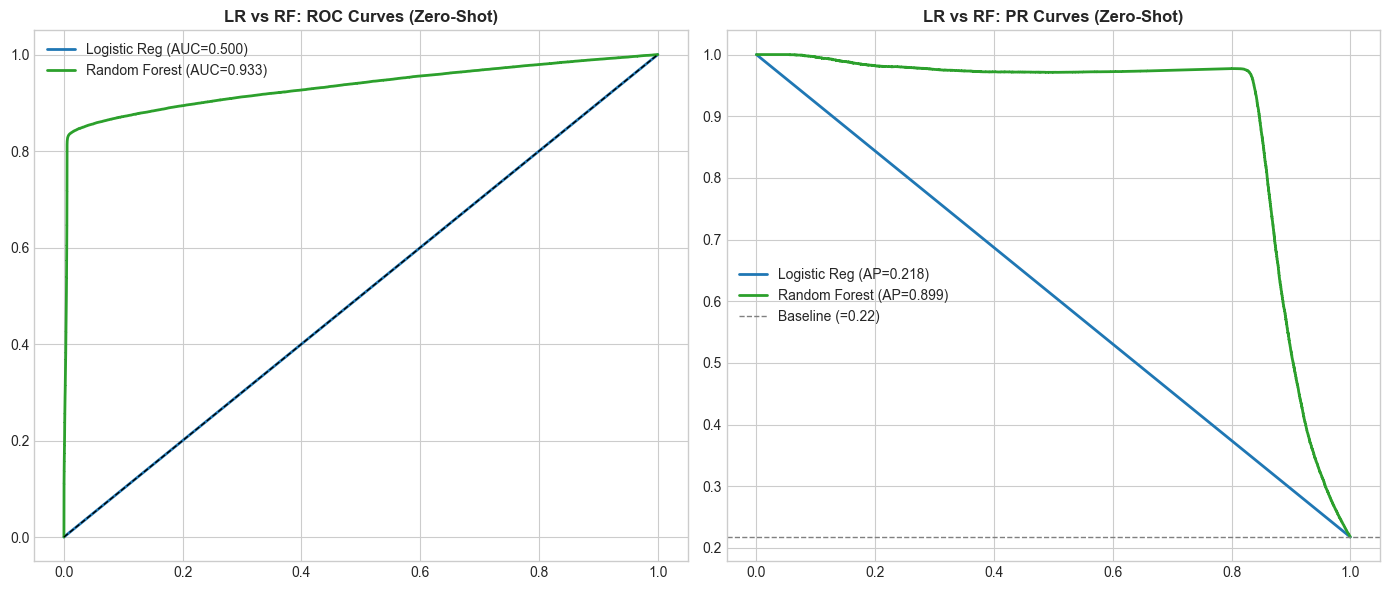

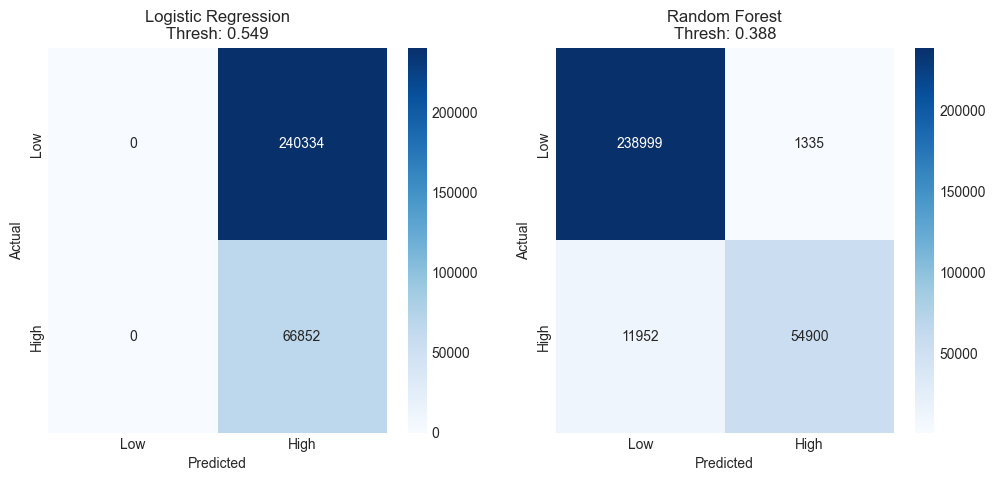

In [38]:
# Plotting ROC & PR Curves for Baseline Models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models = [('Logistic Reg', lr_prob_nibrs, '#1f77b4'), ('Random Forest', rf_prob_nibrs, '#2ca02c')]

# ROC
ax = axes[0]
for name, prob, color in models:
    fpr, tpr, _ = roc_curve(y_nibrs, prob)
    auc = roc_auc_score(y_nibrs, prob)
    ax.plot(fpr, tpr, color=color, label=f'{name} (AUC={auc:.3f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_title("LR vs RF: ROC Curves (Zero-Shot)", fontweight='bold')
ax.legend()

# PR
ax = axes[1]
baseline = y_nibrs.mean()
for name, prob, color in models:
    prec, rec, _ = precision_recall_curve(y_nibrs, prob)
    ap = average_precision_score(y_nibrs, prob)
    ax.plot(rec, prec, color=color, label=f'{name} (AP={ap:.3f})', linewidth=2)
ax.axhline(baseline, color='gray', linestyle='--', linewidth=1, label=f'Baseline (={baseline:.2f})')
ax.set_title("LR vs RF: PR Curves (Zero-Shot)", fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_nibrs, lr_pred_nibrs), annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
axes[0].set_title(f"Logistic Regression\nThresh: {lr_threshold:.3f}")
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_nibrs, rf_pred_nibrs), annot=True, fmt='d', cmap='Blues', ax=axes[1], xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
axes[1].set_title(f"Random Forest\nThresh: {rf_threshold:.3f}")
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
plt.show()



  XGBoost — NIBRS Zero-Shot Performance
  Threshold:  0.4634
  Accuracy:   0.9613
  Precision:  0.9783
  Recall:     0.8410
  F1-Score:   0.9045
  AUC-ROC:    0.9348
  Avg Prec:   0.9060

Classification Report:
              precision    recall  f1-score   support

   Low Crime       0.96      0.99      0.98    240334
  High Crime       0.98      0.84      0.90     66852

    accuracy                           0.96    307186
   macro avg       0.97      0.92      0.94    307186
weighted avg       0.96      0.96      0.96    307186



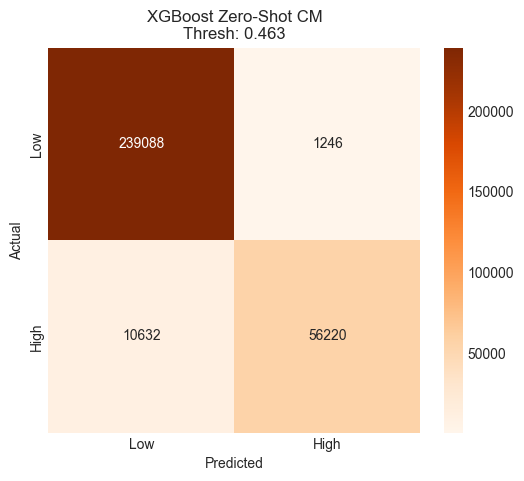

In [39]:
# XGBoost Zero-shot Inference
xgb_prob_nibrs = xgb_best.predict_proba(X_nibrs)[:, 1]
xgb_pred_nibrs = (xgb_prob_nibrs >= xgb_threshold).astype(int)

nibrs_results['XGB'] = evaluate_and_plot('XGBoost', y_nibrs, xgb_prob_nibrs, xgb_pred_nibrs, xgb_threshold)

# XGB Confusion Matrix Comparison
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_nibrs, xgb_pred_nibrs), annot=True, fmt='d', cmap='Oranges', ax=ax, xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
ax.set_title(f"XGBoost Zero-Shot CM\nThresh: {xgb_threshold:.3f}")
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.show()


In [40]:
# 1. 14-Day Sequence Building (FIXED: daily aggregation + train-only normalization)
import numpy as np
import pandas as pd

SEQ_LEN = 14

# Aggregate to daily level per spatial unit (mirrors Chicago LSTM pipeline)
ca_col = 'Community Area' if 'Community Area' in df_nibrs.columns else 'spatial_unit'
date_col = 'date_only' if 'date_only' in df_nibrs.columns else 'date'

agg_dict_nibrs = {
    'crime_count': ('crime_count', 'sum'),
    'high_crime': ('high_crime', 'max'),
}

sum_cols = ['arrest_count', 'domestic_count']
mean_cols = ['lag_1d', 'lag_7d', 'rolling_7d', 'rolling_std_7d', 'rolling_std_30d', 'crime_trend']
calendar_cols = [
    'is_weekend', 'is_payday', 'is_holiday',
    'is_pre_holiday', 'is_post_holiday', 'is_long_weekend',
    'month', 'day_of_month'
]

for col in sum_cols:
    if col in df_nibrs.columns:
        agg_dict_nibrs[col] = (col, 'sum')
for col in mean_cols:
    if col in df_nibrs.columns:
        agg_dict_nibrs[col] = (col, 'mean')
for col in calendar_cols:
    if col in df_nibrs.columns:
        agg_dict_nibrs[col] = (col, 'first')

ts_daily = df_nibrs.groupby([ca_col, date_col]).agg(**agg_dict_nibrs).reset_index()
ts_daily.rename(columns={date_col: 'date_only'}, inplace=True)

ts_daily['date_only'] = pd.to_datetime(ts_daily['date_only'])
ts_daily['dow'] = ts_daily['date_only'].dt.dayofweek
ts_daily['dow_sin'] = np.sin(2 * np.pi * ts_daily['dow'] / 7)
ts_daily['dow_cos'] = np.cos(2 * np.pi * ts_daily['dow'] / 7)

CHICAGO_LSTM_FEATURES = [
    'crime_count',
    'lag_1d', 'lag_7d',
    'rolling_7d', 'rolling_std_7d', 'rolling_std_30d', 'crime_trend',
    'arrest_count', 'domestic_count',
    'dow_sin', 'dow_cos',
    'month', 'day_of_month',
    'is_weekend', 'is_payday',
    'is_holiday', 'is_pre_holiday', 'is_post_holiday', 'is_long_weekend'
]

all_areas = ts_daily[ca_col].unique()
print(f"Building {SEQ_LEN}-day sequences for {len(all_areas)} NIBRS areas...")

sequences, labels, seq_ca, seq_date = [], [], [], []

for ca in all_areas:
    ca_data = ts_daily[ts_daily[ca_col] == ca].sort_values('date_only').copy()

    if len(ca_data) < SEQ_LEN + 1:
        continue

    for col in CHICAGO_LSTM_FEATURES:
        if col not in ca_data.columns:
            ca_data[col] = 0.0

    feat_vals = ca_data[CHICAGO_LSTM_FEATURES].values.astype(float)
    tgts = ca_data['high_crime'].values
    dates = ca_data['date_only'].values

    # Normalize using first 80% of data (train-only) to prevent leakage
    n_train = int(len(feat_vals) * 0.8)
    if n_train < SEQ_LEN:
        n_train = len(feat_vals) - 1
    feat_mean = feat_vals[:n_train].mean(axis=0)
    feat_std = feat_vals[:n_train].std(axis=0) + 1e-8
    feat_vals = (feat_vals - feat_mean) / feat_std

    for i in range(SEQ_LEN, len(feat_vals)):
        sequences.append(feat_vals[i - SEQ_LEN:i])
        labels.append(tgts[i])
        seq_ca.append(ca)
        seq_date.append(dates[i])

X_lstm = np.array(sequences)
y_lstm = np.array(labels)
seq_ca = np.array(seq_ca)
seq_date = np.array(seq_date)

print(f"NIBRS Daily-Aggregated 3D Sequence Tensor: {X_lstm.shape}")


Building 14-day sequences for 107 NIBRS areas...
NIBRS Daily-Aggregated 3D Sequence Tensor: (93768, 14, 19)



  LSTM Network — NIBRS Zero-Shot Performance
  Threshold:  0.5000
  Accuracy:   0.7295
  Precision:  0.7496
  Recall:     0.3493
  F1-Score:   0.4765
  AUC-ROC:    0.7967
  Avg Prec:   0.6851

Classification Report:
              precision    recall  f1-score   support

   Low Crime       0.73      0.94      0.82     60719
  High Crime       0.75      0.35      0.48     33049

    accuracy                           0.73     93768
   macro avg       0.74      0.64      0.65     93768
weighted avg       0.73      0.73      0.70     93768



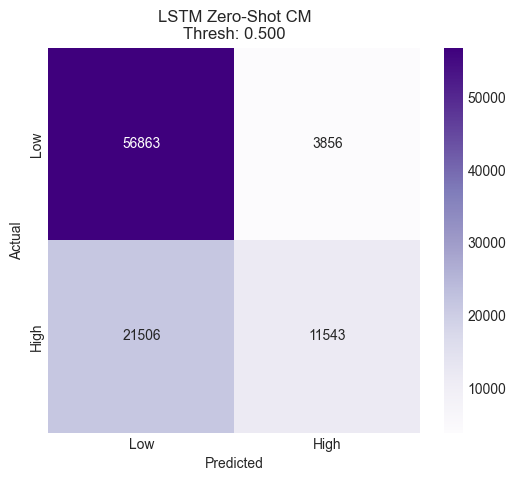

In [41]:
# 2. LSTM Exact Zero-Shot Prediction
if 'lstm_model' in globals() and len(X_lstm) > 0:
    lstm_prob_nibrs = lstm_model.predict(X_lstm, verbose=0).flatten()
    lstm_threshold = 0.5
    lstm_pred_nibrs = (lstm_prob_nibrs > lstm_threshold).astype(int)

    nibrs_results['LSTM'] = evaluate_and_plot('LSTM Network', y_lstm, lstm_prob_nibrs, lstm_pred_nibrs, lstm_threshold)

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_lstm, lstm_pred_nibrs), annot=True, fmt='d', cmap='Purples', ax=ax, xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
    ax.set_title(f"LSTM Zero-Shot CM\nThresh: {lstm_threshold:.3f}")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.show()
else:
    print("Skip plotting LSTM metrics due to missing data or model loading error.")


### 6.2 Cross-domain headline comparison

These plots summarize the zero-shot model ranking on NIBRS and compare the Chicago-native XGBoost headline scores against the NIBRS strict zero-shot outcome.


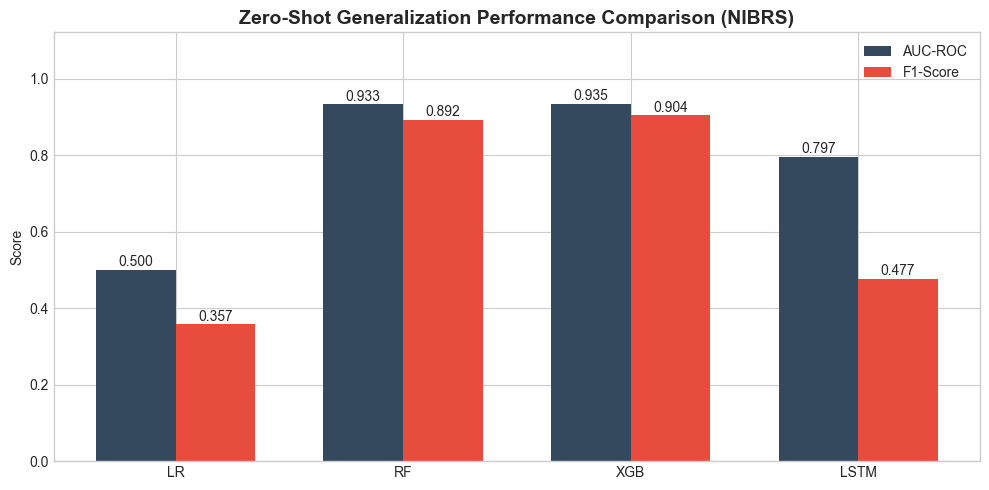

In [42]:
# Summary Plot of All Models
if nibrs_results:
    auc_vals = [res.get('auc', 0) for res in nibrs_results.values()]
    f1_vals = [res.get('f1', 0) for res in nibrs_results.values()]
    names = list(nibrs_results.keys())

    plt.figure(figsize=(10, 5))
    bar_width = 0.35
    x = np.arange(len(names))

    plt.bar(x - bar_width/2, auc_vals, bar_width, label='AUC-ROC', color='#34495e')
    plt.bar(x + bar_width/2, f1_vals, bar_width, label='F1-Score', color='#e74c3c')

    for i, auc in enumerate(auc_vals):
        if auc > 0:
            plt.text(i - bar_width/2, auc + 0.01, f'{auc:.3f}', ha='center')
    for i, f1 in enumerate(f1_vals):
        if f1 > 0:
            plt.text(i + bar_width/2, f1 + 0.01, f'{f1:.3f}', ha='center')

    plt.xticks(x, names)
    plt.ylim(0, max(max(auc_vals + [0]), max(f1_vals + [0])) * 1.2 or 1.0)
    plt.ylabel('Score')
    plt.title('Zero-Shot Generalization Performance Comparison (NIBRS)', fontweight='bold', fontsize=14)
    plt.legend()
    plt.tight_layout()
    plt.show()

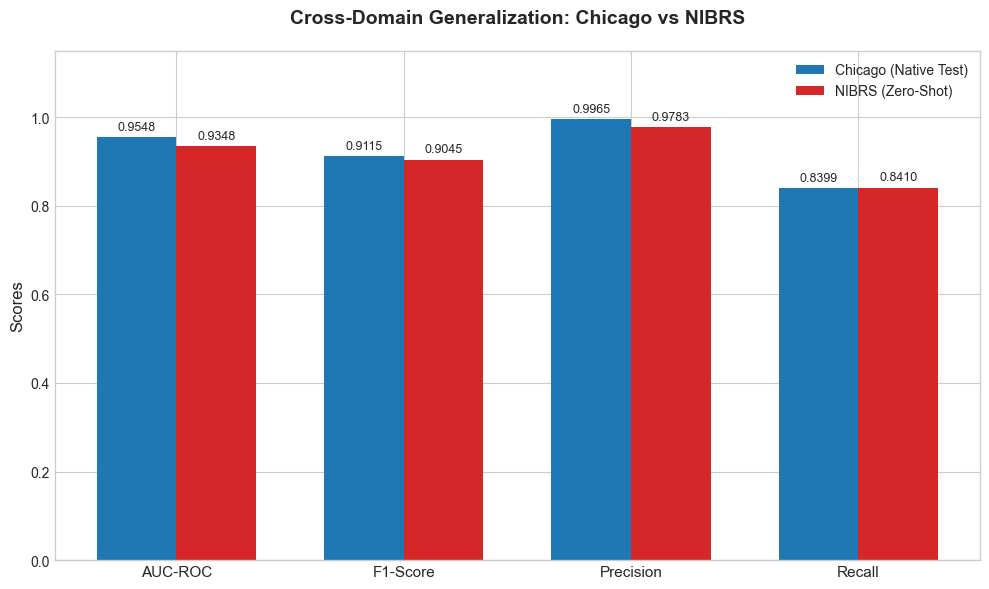

In [43]:
# Cross-Domain Comparison: Chicago (Native) vs NIBRS (Zero-Shot)
from sklearn.metrics import precision_score, recall_score

nibrs_scores = [
    roc_auc_score(y_nibrs, xgb_prob_nibrs),
    f1_score(y_nibrs, xgb_pred_nibrs, zero_division=0),
    precision_score(y_nibrs, xgb_pred_nibrs, zero_division=0),
    recall_score(y_nibrs, xgb_pred_nibrs, zero_division=0),
]
metrics_labels = ['AUC-ROC', 'F1-Score', 'Precision', 'Recall']

# Chicago native scores: directly calculating from 4.4's xgb results
chi_scores = [
    roc_auc_score(y_test, xgb_prob),
    f1_score(y_test, xgb_pred, zero_division=0),
    precision_score(y_test, xgb_pred, zero_division=0),
    recall_score(y_test, xgb_pred, zero_division=0),
]

x = np.arange(len(metrics_labels))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))

if all(v is not None for v in chi_scores):
    bars_chi = ax.bar(x - width/2, chi_scores, width, label='Chicago (Native Test)', color='#1f77b4')
    bars_nib = ax.bar(x + width/2, nibrs_scores, width, label='NIBRS (Zero-Shot)', color='#d62728')
    def _label(rects):
        for rect in rects:
            h = rect.get_height()
            ax.annotate(f'{h:.4f}', xy=(rect.get_x() + rect.get_width()/2, h),
                        xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=9)
    _label(bars_chi); _label(bars_nib)
else:
    bars_nib = ax.bar(x, nibrs_scores, width, label='NIBRS (Zero-Shot)', color='#d62728')
    for rect in bars_nib:
        h = rect.get_height()
        ax.annotate(f'{h:.4f}', xy=(rect.get_x() + rect.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Scores', fontsize=12)
ax.set_title('Cross-Domain Generalization: Chicago vs NIBRS', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()


### 6.3 Official boundary note

The official XGBoost external-validation claim is locked to the Chicago threshold and must stay separate from any target-domain adaptation or retuning.


In [44]:
# Official boundary note: locked Chicago threshold on NIBRS
print('Evaluating XGBoost on NIBRS with the locked Chicago threshold only...')
print('-' * 70)
print(f'Locked Chicago threshold: {xgb_threshold:.4f}')

xgb_pred_locked = (xgb_prob_nibrs >= xgb_threshold).astype(int)
locked_f1 = f1_score(y_nibrs, xgb_pred_locked, zero_division=0)
locked_prec = precision_score(y_nibrs, xgb_pred_locked, zero_division=0)
locked_rec = recall_score(y_nibrs, xgb_pred_locked, zero_division=0)
locked_auc = roc_auc_score(y_nibrs, xgb_prob_nibrs)

print(f'AUC-ROC (threshold-free): {locked_auc:.4f}')
print(f'F1-Score (locked threshold): {locked_f1:.4f}')
print(f'Precision: {locked_prec:.4f}')
print(f'Recall:    {locked_rec:.4f}')
print('\nLocked-threshold classification report:')
print(classification_report(y_nibrs, xgb_pred_locked, target_names=['Low Crime', 'High Crime'], zero_division=0))
print('[Boundary] Chapter 6 treats this locked-threshold result as the official NIBRS XGBoost outcome.')
print('[Boundary] Any target-domain adaptation or threshold retuning is deferred to Chapter 8.')


Evaluating XGBoost on NIBRS with the locked Chicago threshold only...
----------------------------------------------------------------------
Locked Chicago threshold: 0.4634
AUC-ROC (threshold-free): 0.9348
F1-Score (locked threshold): 0.9045
Precision: 0.9783
Recall:    0.8410

Locked-threshold classification report:
              precision    recall  f1-score   support

   Low Crime       0.96      0.99      0.98    240334
  High Crime       0.98      0.84      0.90     66852

    accuracy                           0.96    307186
   macro avg       0.97      0.92      0.94    307186
weighted avg       0.96      0.96      0.96    307186

[Boundary] Chapter 6 treats this locked-threshold result as the official NIBRS XGBoost outcome.
[Boundary] Any target-domain adaptation or threshold retuning is deferred to Chapter 8.


---
## 7. Diagnostic Analysis [Supporting]

### 7.0 Diagnostic scope

These diagnostics explain **why** the Chicago-to-NIBRS transfer behaves the way it does. They support the official results but do not replace them.



### 7.1 SHAP and feature stability

This subsection explains the Chicago-side feature drivers behind the tabular models and serves as the starting point for the supporting diagnostic analysis.



100%|██████████| 1000/1000 [00:10<00:00, 93.17it/s]


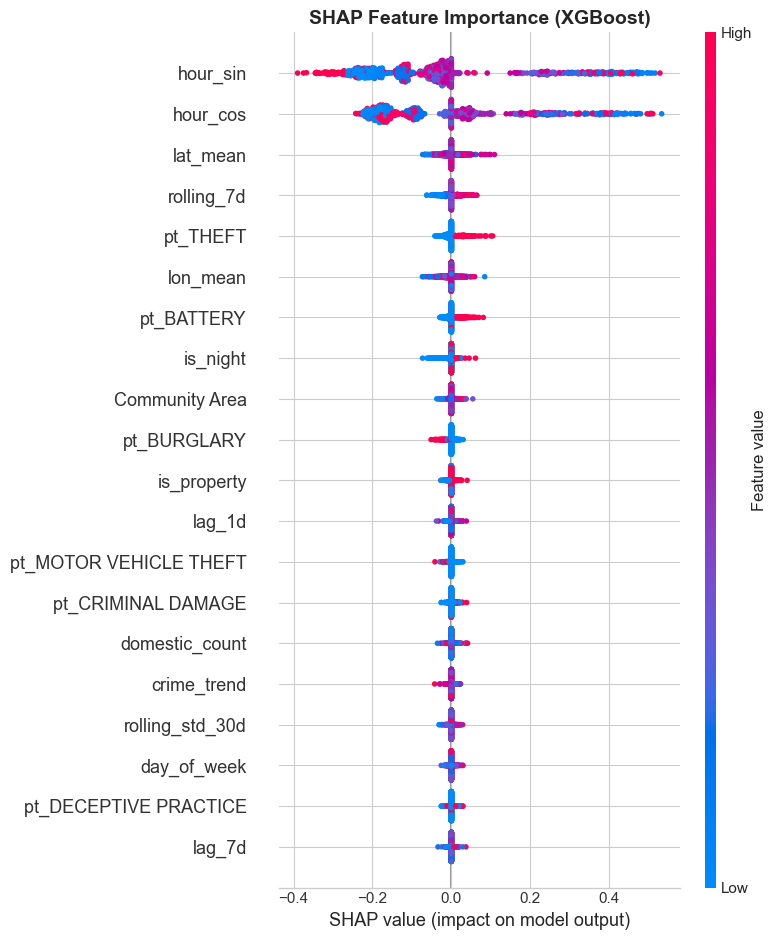

In [45]:
# SHAP Analysis on XGBoost
# TreeExplainer currently fails due to xgboost base_score formatting issues ("[5E-1]").
# Use KernelExplainer as a robust fallback (slower but works reliably).

sample_idx = np.random.choice(len(X_test), min(1000, len(X_test)), replace=False)
X_shap = X_test[sample_idx]

# Use a small background sample for KernelExplainer to keep runtime reasonable.
background = shap.sample(X_train, 100, random_state=RANDOM_STATE)
model_fn = lambda x: xgb_best.predict_proba(x)[:, 1]
explainer = shap.KernelExplainer(model_fn, background)
shap_values = explainer.shap_values(X_shap, nsamples=100)

# SHAP Summary Plot (Beeswarm)
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_COLS, show=False)
plt.title('SHAP Feature Importance (XGBoost)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

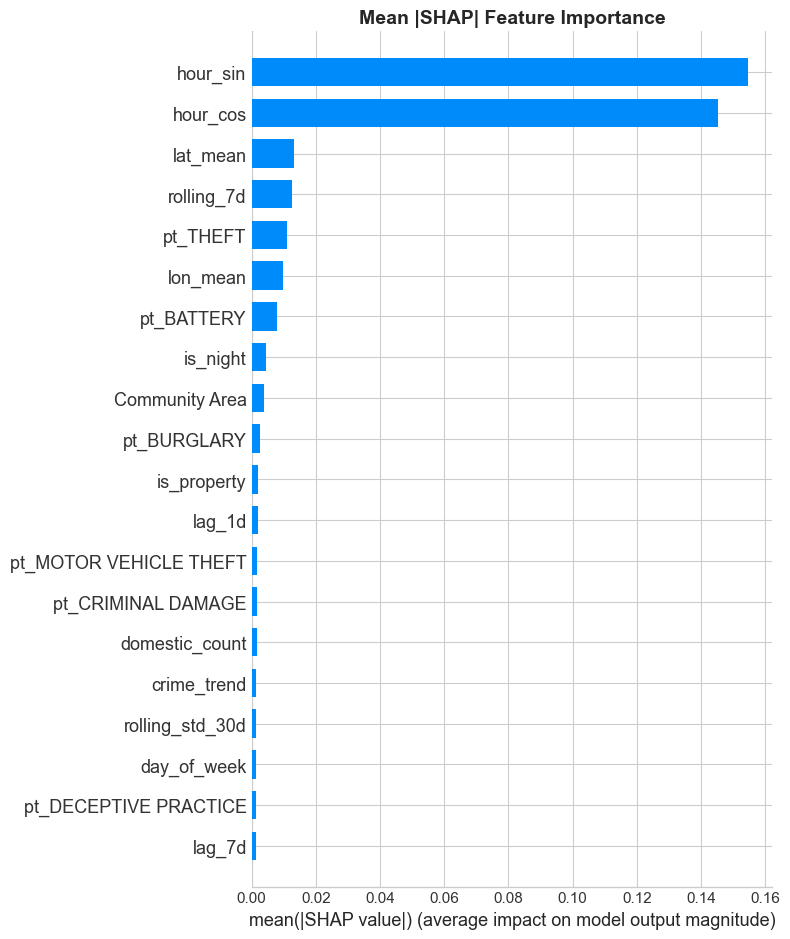


Top 10 Features by Mean |SHAP| Value:
       Feature  Mean |SHAP|
      hour_sin       0.1546
      hour_cos       0.1455
      lat_mean       0.0133
    rolling_7d       0.0125
      pt_THEFT       0.0111
      lon_mean       0.0098
    pt_BATTERY       0.0079
      is_night       0.0045
Community Area       0.0039
   pt_BURGLARY       0.0025


In [46]:
# SHAP Bar Plot (Mean |SHAP|)
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_COLS, plot_type='bar', show=False)
plt.title('Mean |SHAP| Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top features
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False)

print("\nTop 10 Features by Mean |SHAP| Value:")
print(feature_importance.head(10).to_string(index=False))

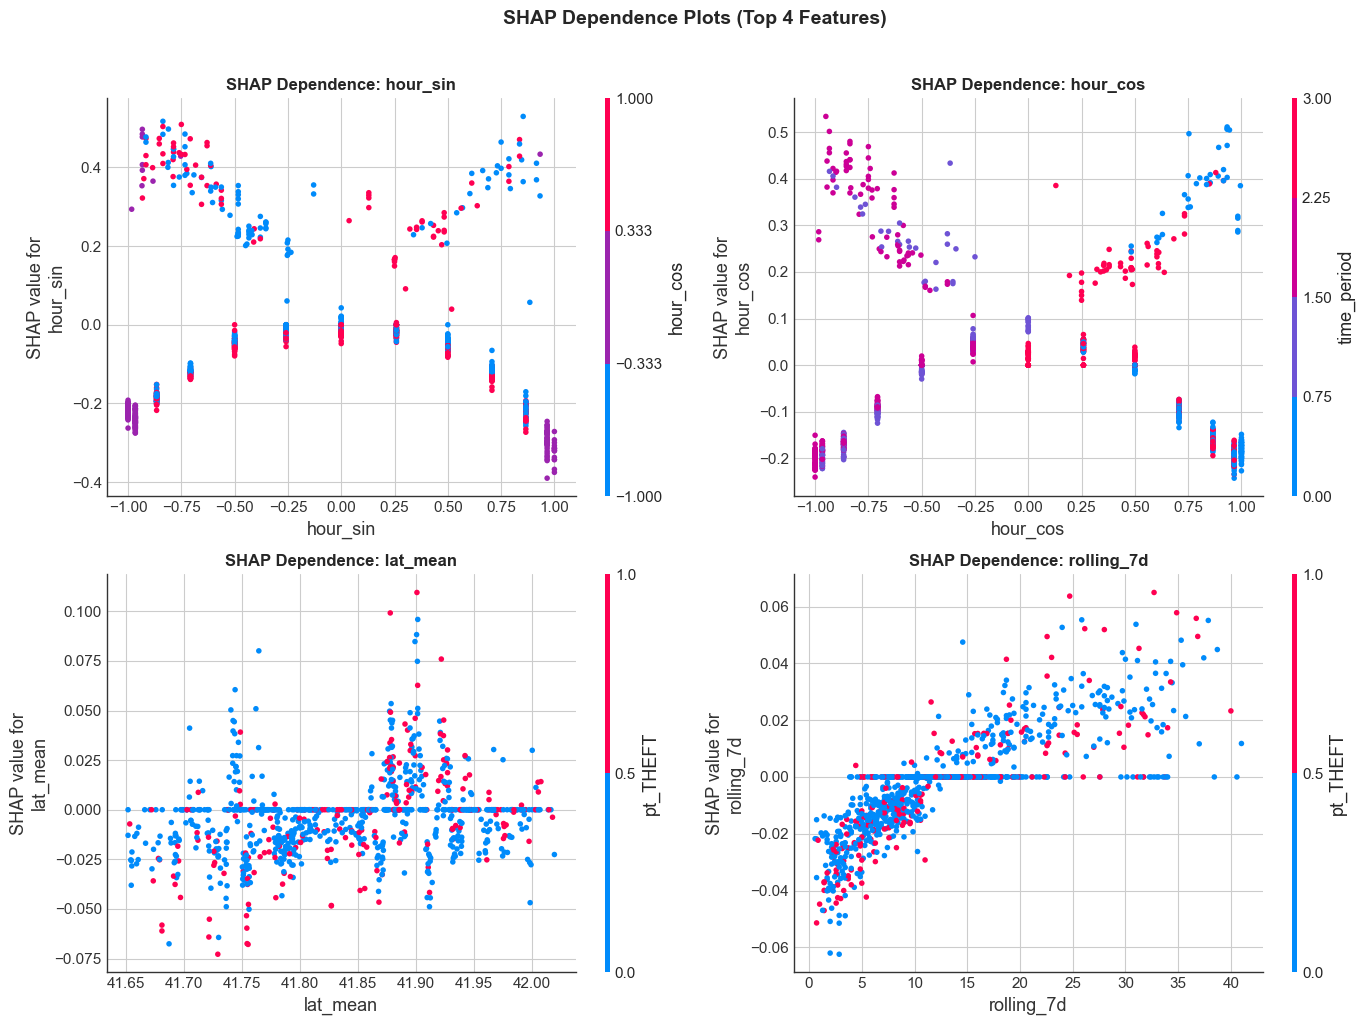

In [47]:
# SHAP Dependence Plots for Top 4 Features
mean_abs = np.abs(shap_values).mean(axis=0)
top_feature_idx = np.argsort(mean_abs)[-4:][::-1]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, fi in enumerate(top_feature_idx):
    ax = axes[i//2, i%2]
    shap.dependence_plot(fi, shap_values, X_shap, feature_names=FEATURE_COLS, ax=ax, show=False)
    ax.set_title(f'SHAP Dependence: {FEATURE_COLS[fi]}', fontweight='bold')

plt.suptitle('SHAP Dependence Plots (Top 4 Features)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7.2 Cross-domain error slices and micro validation

This subsection highlights local behaviors and failure patterns that do not belong in the official headline results but help explain model behavior across domains.


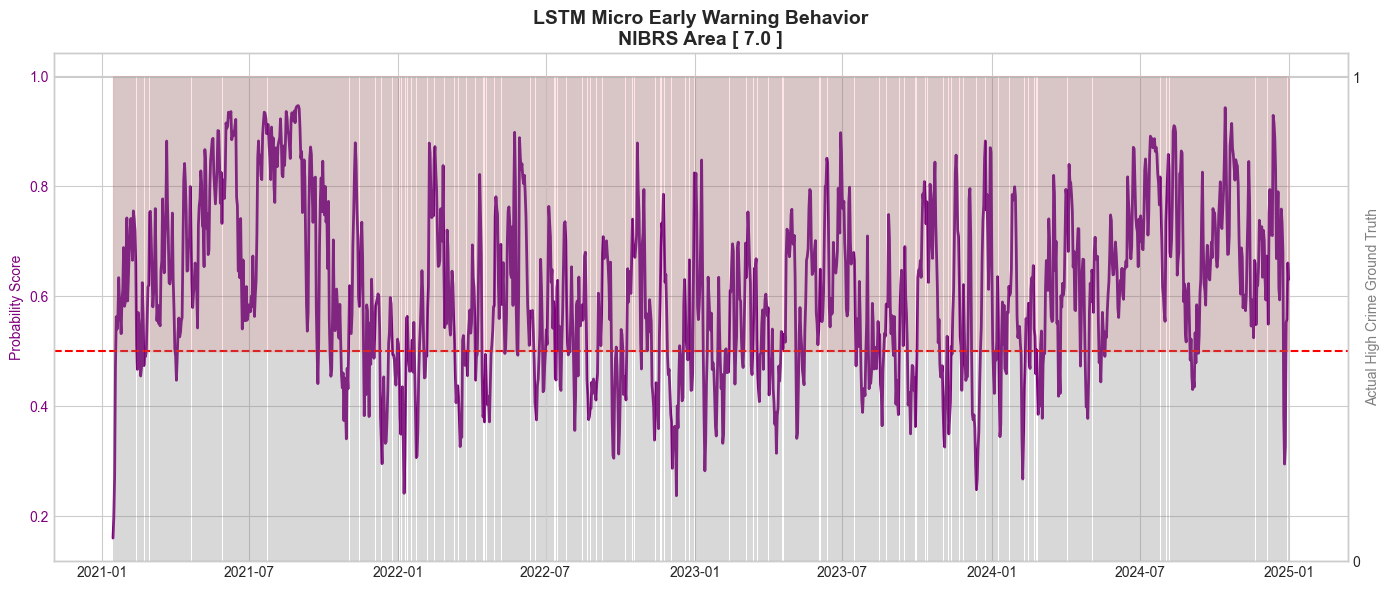

In [48]:
# 3. Micro Validation: Early-warning Trend Case Study
import matplotlib.dates as mdates

if 'lstm_prob_nibrs' in locals() and len(seq_ca) > 0:
    unique_cas, counts = np.unique(seq_ca, return_counts=True)
    top_ca = unique_cas[np.argmax(counts)]

    mask = (seq_ca == top_ca)
    ca_dates = seq_date[mask]
    ca_true = y_lstm[mask]
    ca_probs = lstm_prob_nibrs[mask]

    fig, ax1 = plt.subplots(figsize=(14, 6))

    ax1.plot(ca_dates, ca_probs, color='purple', linewidth=2, label='LSTM High Risk Probability')
    ax1.set_ylabel('Probability Score', color='purple')
    ax1.tick_params(axis='y', labelcolor='purple')

    ax1.axhline(0.5, color='red', linestyle='--', label='Alert Threshold')
    ax1.fill_between(ca_dates, 0.5, 1, color='red', alpha=0.1)

    ax2 = ax1.twinx()
    ax2.bar(ca_dates, ca_true, width=1.0, color='grey', alpha=0.3, label='Actual High Crime Incident')
    ax2.set_ylabel('Actual High Crime Ground Truth', color='grey')
    ax2.set_yticks([0, 1])

    plt.title(f"LSTM Micro Early Warning Behavior\nNIBRS Area [ {top_ca} ]", fontweight='bold', fontsize=14)
    fig.tight_layout()
    plt.show()


### 7.3 Chicago vs NIBRS SHAP comparison

These cells compare the dominant XGBoost features across the source and target domains and support the feature-stability narrative.


In [49]:
# Setup: aligned DataFrame wrappers for error analysis & SHAP force plots
df_nibrs_test_reset = df_nibrs_test.reset_index(drop=True)
X_nibrs_df = df_nibrs_test_reset.reindex(columns=FEATURE_COLS, fill_value=0)
print(f"X_nibrs_df (aligned, reset index): {X_nibrs_df.shape}")

X_nibrs_df (aligned, reset index): (307186, 34)


Comparing Feature Importance: Chicago vs NIBRS (XGBoost SHAP)
------------------------------------------------------------


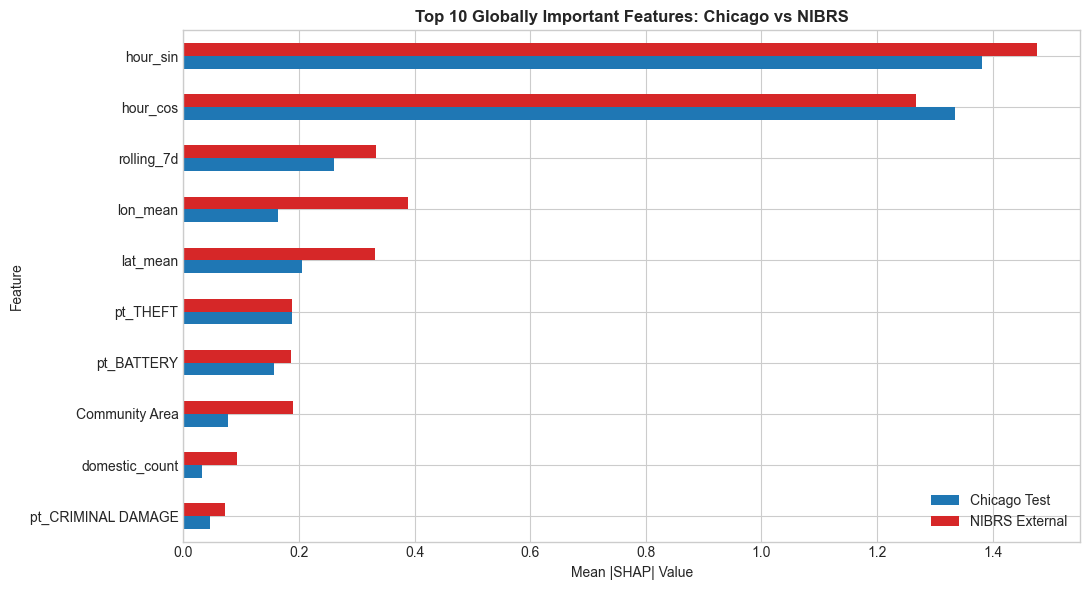

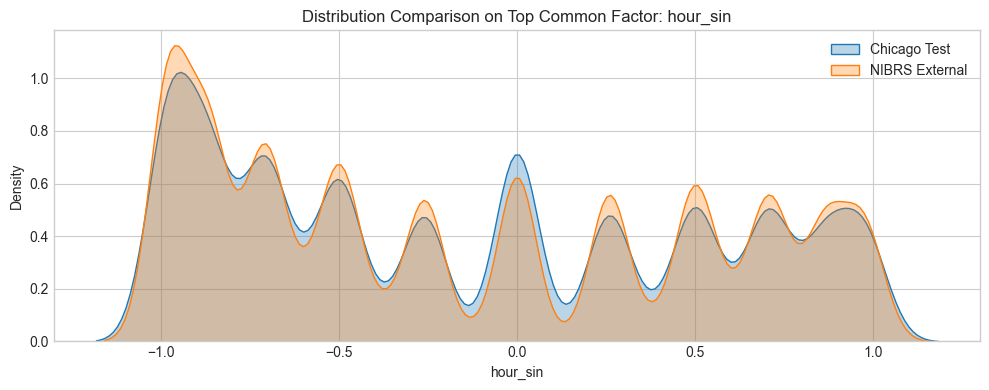

Number 1 Globally Important Feature: hour_sin
  Chicago mean |SHAP| = 1.381244
  NIBRS   mean |SHAP| = 1.477045


,Feature,Chicago_SHAP,NIBRS_SHAP,Common_Importance
2,hour_sin,1.3812,1.4770,1.4291
3,hour_cos,1.3350,1.2674,1.3012
20,rolling_7d,0.2615,0.3337,0.2976
17,lon_mean,0.1632,0.3892,0.2762
16,lat_mean,0.2048,0.3315,0.2681
33,pt_THEFT,0.1872,0.1873,0.1872
28,pt_BATTERY,0.1574,0.1857,0.1715
0,Community Area,0.0776,0.1902,0.1339
25,domestic_count,0.0326,0.0921,0.0623
30,pt_CRIMINAL DAMAGE,0.0468,0.0718,0.0593


In [50]:
# SHAP Feature Importance: Chicago vs NIBRS (XGBoost)
from IPython.display import display
print("Comparing Feature Importance: Chicago vs NIBRS (XGBoost SHAP)")
print("-" * 60)

required_vars = ['xgb_best', 'X_test', 'X_nibrs', 'FEATURE_COLS']
missing_vars = [v for v in required_vars if v not in locals()]

if missing_vars:
    print(f"Missing required variables: {missing_vars}")
else:
    X_chicago_df = pd.DataFrame(X_test, columns=FEATURE_COLS)
    X_nibrs_plot_df = X_nibrs_df.copy() if 'X_nibrs_df' in locals() else pd.DataFrame(X_nibrs, columns=FEATURE_COLS)

    # Sample both domains for fair and lightweight SHAP comparison
    chi_shap_sample_n = min(500, len(X_test))
    nib_shap_sample_n = min(500, len(X_nibrs))

    X_chicago_shap = X_test[np.random.choice(len(X_test), chi_shap_sample_n, replace=False)]
    X_nibrs_shap = X_nibrs[np.random.choice(len(X_nibrs), nib_shap_sample_n, replace=False)]

    def compute_shap_values(model, X_sample, X_background):
        try:
            domain_explainer = shap.TreeExplainer(model)
            values = domain_explainer.shap_values(X_sample)
        except Exception:
            bg_n = min(100, len(X_background))
            bg = X_background[np.random.choice(len(X_background), bg_n, replace=False)]
            domain_explainer = shap.KernelExplainer(lambda x: model.predict_proba(x)[:, 1], bg)
            values = domain_explainer.shap_values(X_sample, nsamples=100)
        return values

    chicago_shap_values = compute_shap_values(xgb_best, X_chicago_shap, X_test)
    nibrs_shap_values = compute_shap_values(xgb_best, X_nibrs_shap, X_nibrs)

    mean_abs_chicago = np.abs(chicago_shap_values).mean(axis=0)
    mean_abs_nibrs = np.abs(nibrs_shap_values).mean(axis=0)

    feat_comp = pd.DataFrame({
        'Feature': FEATURE_COLS,
        'Chicago_SHAP': mean_abs_chicago,
        'NIBRS_SHAP': mean_abs_nibrs
    })

    feat_comp['Common_Importance'] = (feat_comp['Chicago_SHAP'] + feat_comp['NIBRS_SHAP']) / 2
    feat_comp_top = feat_comp.sort_values('Common_Importance', ascending=False).head(10)

    plot_df = feat_comp_top.sort_values('Common_Importance', ascending=True).set_index('Feature')[
        ['Chicago_SHAP', 'NIBRS_SHAP']
    ]

    fig, ax = plt.subplots(figsize=(11, 6))
    plot_df.plot(kind='barh', ax=ax, color=['#1f77b4', '#d62728'])
    ax.set_title("Top 10 Globally Important Features: Chicago vs NIBRS", fontweight='bold')
    ax.set_xlabel("Mean |SHAP| Value")
    ax.set_ylabel("Feature")
    ax.legend(['Chicago Test', 'NIBRS External'])
    plt.tight_layout()
    plt.show()

    top_common_feature = feat_comp_top.iloc[0]['Feature']

    if top_common_feature in X_chicago_df.columns and top_common_feature in X_nibrs_plot_df.columns:
        plt.figure(figsize=(10, 4))
        sns.kdeplot(X_chicago_df[top_common_feature], label='Chicago Test', fill=True, alpha=0.30)
        sns.kdeplot(X_nibrs_plot_df[top_common_feature], label='NIBRS External', fill=True, alpha=0.30)
        plt.title(f"Distribution Comparison on Top Common Factor: {top_common_feature}")
        plt.legend()
        plt.tight_layout()
        plt.show()

    print(f"Number 1 Globally Important Feature: {top_common_feature}")
    print(f"  Chicago mean |SHAP| = {feat_comp_top.iloc[0]['Chicago_SHAP']:.6f}")
    print(f"  NIBRS   mean |SHAP| = {feat_comp_top.iloc[0]['NIBRS_SHAP']:.6f}")

    display(feat_comp_top[['Feature', 'Chicago_SHAP', 'NIBRS_SHAP', 'Common_Importance']])


### 7.4 Monthly drift and calibration

These diagnostics track whether the strict zero-shot XGBoost behavior remains stable over time and whether its probabilities stay calibrated on NIBRS.


Monthly NIBRS performance metrics:
        month  n_samples  positive_rate  auc_roc  f1_score  precision  recall
0  2021-01-01  6256.0000         0.2001   0.9315    0.8962     0.9774  0.8275
1  2021-02-01  5217.0000         0.1917   0.9248    0.8800     0.9676  0.8070
2  2021-03-01  6047.0000         0.2036   0.9384    0.9062     0.9783  0.8440
3  2021-04-01  5535.0000         0.1966   0.9305    0.8968     0.9691  0.8346
4  2021-05-01  6412.0000         0.2035   0.9205    0.8897     0.9736  0.8192
5  2021-06-01  6448.0000         0.2067   0.9318    0.9051     0.9749  0.8447
6  2021-07-01  6806.0000         0.2235   0.9373    0.9086     0.9809  0.8462
7  2021-08-01  6811.0000         0.2016   0.9291    0.8992     0.9745  0.8347
8  2021-09-01  6622.0000         0.2108   0.9325    0.9051     0.9760  0.8438
9  2021-10-01  6767.0000         0.2183   0.9348    0.9086     0.9881  0.8409
10 2021-11-01  6359.0000         0.2279   0.9359    0.9074     0.9839  0.8420
11 2021-12-01  6271.0000     

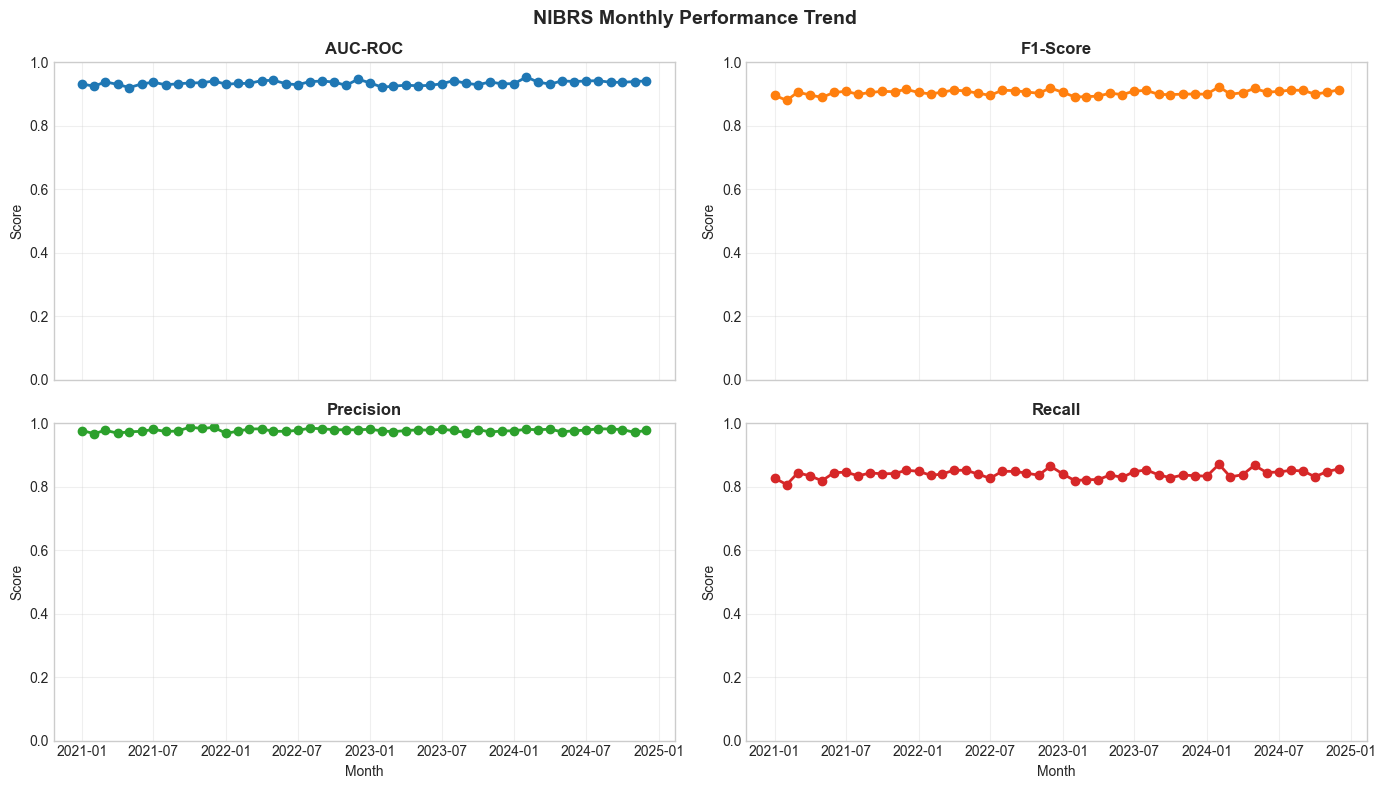


CONCEPT DRIFT CONCLUSION
Range: 2021-01-01 to 2024-12-01 (48 months)
Avg AUC=0.9349, Avg F1=0.9042
Delta late-early: AUC=0.0050, F1=0.0035
CV: AUC=0.0070, F1=0.0089 | Slope: AUC=0.00016, F1=0.00016

Conclusion: Model performance is relatively stable; no clear concept drift signal.


In [51]:
# Monthly Performance Trend + Concept Drift Detection
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

dfm = df_nibrs_test.copy().reset_index(drop=True)
dfm['month'] = pd.to_datetime(dfm['date_only'], errors='coerce').dt.to_period('M').dt.to_timestamp()
dfm['y_true'] = np.asarray(y_nibrs).astype(int)
dfm['y_prob'] = np.asarray(xgb_prob_nibrs).astype(float)
dfm['y_pred'] = (dfm['y_prob'] >= float(xgb_threshold)).astype(int)
dfm = dfm.dropna(subset=['month']).sort_values('month')

def month_metrics(g):
    y_t, y_p, y_pr = g['y_true'].values, g['y_pred'].values, g['y_prob'].values
    return pd.Series({
        'n_samples':    len(g),
        'positive_rate': y_t.mean(),
        'auc_roc':   roc_auc_score(y_t, y_pr) if np.unique(y_t).size > 1 else np.nan,
        'f1_score':  f1_score(y_t, y_p, zero_division=0),
        'precision': precision_score(y_t, y_p, zero_division=0),
        'recall':    recall_score(y_t, y_p, zero_division=0),
    })

monthly_metrics = dfm.groupby('month').apply(month_metrics).reset_index()
print('Monthly NIBRS performance metrics:')
print(monthly_metrics.round(4).to_string())

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, (col, title, color) in zip(axes.flat, [
    ('auc_roc',   'AUC-ROC',   '#1f77b4'),
    ('f1_score',  'F1-Score',  '#ff7f0e'),
    ('precision', 'Precision', '#2ca02c'),
    ('recall',    'Recall',    '#d62728'),
]):
    ax.plot(monthly_metrics['month'], monthly_metrics[col], marker='o', linewidth=2, color=color)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
for ax in axes[1, :]:
    ax.set_xlabel('Month')
plt.suptitle('NIBRS Monthly Performance Trend', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

def _slope(s):
    s = pd.Series(s).dropna()
    return np.nan if len(s) < 2 else float(np.polyfit(np.arange(len(s)), s.values, 1)[0])

def _cv(s):
    s = pd.Series(s).dropna()
    return np.nan if len(s) < 2 or s.mean() == 0 else float(s.std(ddof=0) / s.mean())

auc_m, f1_m = monthly_metrics['auc_roc'], monthly_metrics['f1_score']
k = max(1, len(monthly_metrics) // 3)
d_auc = float(monthly_metrics.tail(k)['auc_roc'].mean() - monthly_metrics.head(k)['auc_roc'].mean())
d_f1  = float(monthly_metrics.tail(k)['f1_score'].mean() - monthly_metrics.head(k)['f1_score'].mean())
auc_slope, f1_slope = _slope(auc_m), _slope(f1_m)
auc_cv,    f1_cv    = _cv(auc_m),    _cv(f1_m)

flags = []
if len(monthly_metrics) < 6:   flags.append('months<6 (low confidence)')
if d_auc < -0.05:               flags.append(f'AUC drop ({d_auc:.3f})')
if d_f1  < -0.08:               flags.append(f'F1 drop ({d_f1:.3f})')
if auc_cv > 0.15:               flags.append(f'AUC volatile (CV={auc_cv:.3f})')
if f1_cv  > 0.20:               flags.append(f'F1 volatile (CV={f1_cv:.3f})')
if auc_slope < -0.003:          flags.append(f'AUC negative slope ({auc_slope:.4f}/month)')
if f1_slope  < -0.005:          flags.append(f'F1 negative slope ({f1_slope:.4f}/month)')

print('\n' + '=' * 70)
print('CONCEPT DRIFT CONCLUSION')
print('=' * 70)
print(f"Range: {monthly_metrics['month'].min().date()} to {monthly_metrics['month'].max().date()} ({len(monthly_metrics)} months)")
print(f"Avg AUC={auc_m.mean():.4f}, Avg F1={f1_m.mean():.4f}")
print(f"Delta late-early: AUC={d_auc:.4f}, F1={d_f1:.4f}")
print(f"CV: AUC={auc_cv:.4f}, F1={f1_cv:.4f} | Slope: AUC={auc_slope:.5f}, F1={f1_slope:.5f}")
if flags:
    print('\nConclusion: Potential concept drift / instability detected.')
    for flag in flags:
        print(f'  - {flag}')
else:
    print('\nConclusion: Model performance is relatively stable; no clear concept drift signal.')


Evaluating probabilistic reliability across domains...


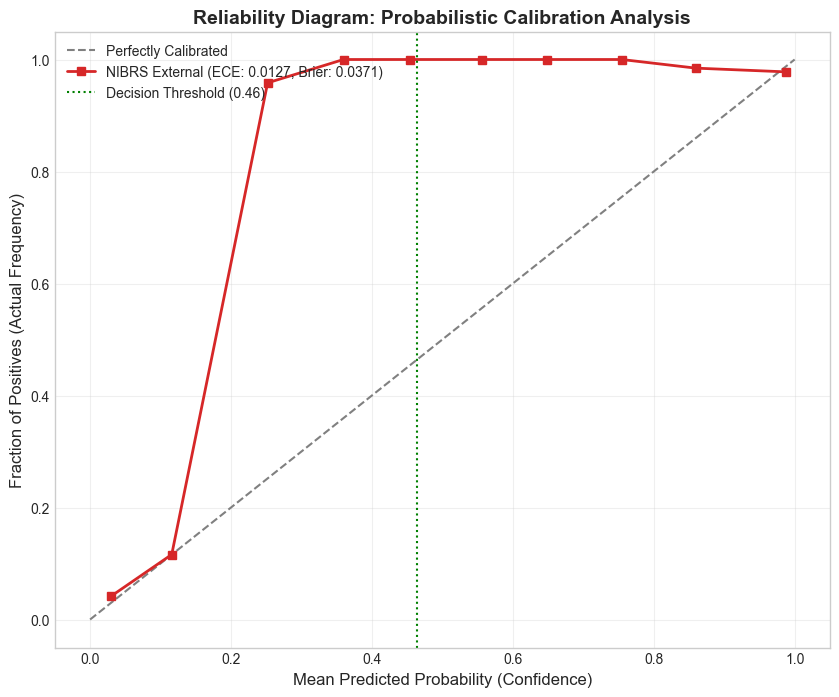

------------------------------------------------------------
NIBRS (External) ECE:         0.0127
NIBRS (External) Brier Score: 0.0371
------------------------------------------------------------
DIAGNOSIS:
Model maintains consistent probabilistic calibration on NIBRS.
------------------------------------------------------------


In [52]:
# Probabilistic Calibration Analysis (ECE / Brier)
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

def calculate_ece(y_true, y_prob, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0
    for idx, (bl, bu) in enumerate(zip(bin_boundaries[:-1], bin_boundaries[1:])):
        in_bin = (y_prob >= bl) & (y_prob <= bu) if idx == 0 else (y_prob > bl) & (y_prob <= bu)
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            ece += np.abs(np.mean(y_prob[in_bin]) - np.mean(y_true[in_bin])) * prop_in_bin
    return ece

print("Evaluating probabilistic reliability across domains...")

prob_true_nib, prob_pred_nib = calibration_curve(y_nibrs, xgb_prob_nibrs, n_bins=10)
ece_nib   = calculate_ece(y_nibrs, xgb_prob_nibrs)
brier_nib = brier_score_loss(y_nibrs, xgb_prob_nibrs)

plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.plot(prob_pred_nib, prob_true_nib, marker='s', linewidth=2, color='#d62728',
         label=f'NIBRS External (ECE: {ece_nib:.4f}, Brier: {brier_nib:.4f})')
plt.axvline(x=xgb_threshold, color='green', linestyle=':',
            label=f'Decision Threshold ({xgb_threshold:.2f})')
plt.xlabel('Mean Predicted Probability (Confidence)', fontsize=12)
plt.ylabel('Fraction of Positives (Actual Frequency)', fontsize=12)
plt.title('Reliability Diagram: Probabilistic Calibration Analysis', fontsize=14, fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

print("-" * 60)
print(f"NIBRS (External) ECE:         {ece_nib:.4f}")
print(f"NIBRS (External) Brier Score: {brier_nib:.4f}")
print("-" * 60)
print("DIAGNOSIS:")
mean_pred = np.mean(xgb_prob_nibrs)
mean_true = np.mean(y_nibrs)
if abs(mean_pred - mean_true) > 0.05:
    direction = "OVERCONFIDENT" if mean_pred > mean_true else "UNDERCONFIDENT"
    print(f"The model is {direction} on NIBRS (Predicted={mean_pred:.3f} vs Actual={mean_true:.3f}).")
else:
    print("Model maintains consistent probabilistic calibration on NIBRS.")
print("-" * 60)


---
## 8. Localization Potential Probe [Exploratory]

### 8.1 Chronological 20% adaptation protocol

This section is **exploratory**. It does not replace the strict zero-shot external-validation results from Chapter 6.

- **Strict zero-shot baseline**: directly apply the Chicago-trained XGBoost model to NIBRS and keep the original Chicago threshold fixed.
- **20% adaptation probe**: use only the earliest 20% chronological NIBRS window for lightweight local adaptation, then evaluate on the later 80% window.
- Only the adaptation branch is allowed to use the earlier 20% labels for threshold tuning.



### 8.2 Strict zero-shot vs adaptation probe

The two cells below compare the locked-threshold strict zero-shot baseline against the chronological 20% adaptation probe on the later 80% window.


In [53]:
# Strict Zero-Shot vs 20% Adaptation Probe Setup
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

X_nib = X_nibrs.copy()
y_nib = y_nibrs.astype(int)

if 'date_only' in df_nibrs_test.columns:
    nibrs_dates = pd.to_datetime(df_nibrs_test['date_only'], errors='coerce')
elif 'date' in df_nibrs_test.columns:
    nibrs_dates = pd.to_datetime(df_nibrs_test['date'], errors='coerce')
else:
    raise KeyError('Chapter 11 requires a date column (`date_only` or `date`) for chronological splitting.')

valid_date_mask = nibrs_dates.notna().to_numpy()
if not valid_date_mask.all():
    raise ValueError('Chronological adaptation probe requires valid timestamps for every NIBRS row.')

unique_dates = np.sort(nibrs_dates.unique())
if len(unique_dates) < 2:
    raise RuntimeError('Need at least two distinct NIBRS dates for the chronological 20/80 split.')

n_adapt_dates = max(1, min(len(unique_dates) - 1, int(np.ceil(len(unique_dates) * 0.20))))
adapt_end_date = unique_dates[n_adapt_dates - 1]

adapt_mask = (nibrs_dates <= adapt_end_date).to_numpy()
eval_mask = (nibrs_dates > adapt_end_date).to_numpy()
if not eval_mask.any():
    adapt_mask = (nibrs_dates < adapt_end_date).to_numpy()
    eval_mask = (nibrs_dates >= adapt_end_date).to_numpy()

idx_ft = np.flatnonzero(adapt_mask)
idx_eval = np.flatnonzero(eval_mask)
if len(idx_ft) == 0 or len(idx_eval) == 0:
    raise RuntimeError('Chronological 20/80 split produced an empty adaptation or evaluation set.')

X_ft,   y_ft   = X_nib[idx_ft],   y_nib[idx_ft]
X_eval, y_eval = X_nib[idx_eval], y_nib[idx_eval]

def best_f1_threshold(y_true, y_prob):
    p, r, t = precision_recall_curve(y_true, y_prob)
    if len(t) == 0:
        return 0.5
    f1_arr = 2 * p[:-1] * r[:-1] / np.clip(p[:-1] + r[:-1], 1e-12, None)
    return float(t[int(np.nanargmax(f1_arr))])

def eval_metrics(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    return {
        'AUC-ROC':   roc_auc_score(y_true, y_prob) if np.unique(y_true).size > 1 else np.nan,
        'F1-Score':  f1_score(y_true, y_pred, zero_division=0),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'Threshold': thr,
    }

# Strict zero-shot baseline: no NIBRS label-based threshold tuning
zs_prob_eval = xgb_best.predict_proba(X_eval)[:, 1]
zs_thr = float(xgb_threshold)
zs_metrics = eval_metrics(y_eval, zs_prob_eval, zs_thr)

# 20% adaptation probe: warm-start from the Chicago booster and tune threshold only on the earlier 20% split
ft_params = xgb_best.get_params()
ft_lr = min(float(ft_params.get('learning_rate', 0.05)), 0.05)
ft_n_rounds = 120

xgb_ft = xgb.XGBClassifier(**ft_params)
xgb_ft.set_params(learning_rate=ft_lr, n_estimators=ft_n_rounds, random_state=RANDOM_STATE)
xgb_ft.fit(X_ft, y_ft, xgb_model=xgb_best.get_booster(), verbose=False)

ft_prob_ft = xgb_ft.predict_proba(X_ft)[:, 1]
ft_thr = best_f1_threshold(y_ft, ft_prob_ft)
ft_prob_eval = xgb_ft.predict_proba(X_eval)[:, 1]
ft_metrics = eval_metrics(y_eval, ft_prob_eval, ft_thr)

adapt_start = pd.Timestamp(unique_dates[0]).date()
adapt_end = pd.Timestamp(adapt_end_date).date()
eval_start = pd.Timestamp(nibrs_dates.iloc[idx_eval[0]]).date()
eval_end = pd.Timestamp(nibrs_dates.iloc[idx_eval[-1]]).date()
print(f'Adaptation window: {adapt_start} to {adapt_end} | samples={len(idx_ft):,} ({len(idx_ft)/len(X_nib):.1%})')
print(f'Evaluation window: {eval_start} to {eval_end} | samples={len(idx_eval):,} ({len(idx_eval)/len(X_nib):.1%})')
print(f'Strict zero-shot threshold (locked from Chicago): {zs_thr:.4f}')
print(f'Adaptation threshold (tuned on the 20% split only): {ft_thr:.4f}')



Adaptation window: 2021-01-01 to 2021-10-20 | samples=60,526 (19.7%)
Evaluation window: 2021-10-21 to 2024-12-17 | samples=246,660 (80.3%)
Strict zero-shot threshold (locked from Chicago): 0.4634
Adaptation threshold (tuned on the 20% split only): 0.6337


In [54]:
# Strict Zero-Shot vs 20% Adaptation Probe Results
comp = pd.DataFrame([
    {'Setting': 'Strict zero-shot (Chicago threshold)', **zs_metrics},
    {'Setting': '20% adaptation probe',               **ft_metrics},
])

delta = {
    'Setting':   'Delta (Adaptation - Zero-shot)',
    'AUC-ROC':   comp.loc[1, 'AUC-ROC']   - comp.loc[0, 'AUC-ROC'],
    'F1-Score':  comp.loc[1, 'F1-Score']  - comp.loc[0, 'F1-Score'],
    'Precision': comp.loc[1, 'Precision'] - comp.loc[0, 'Precision'],
    'Recall':    comp.loc[1, 'Recall']    - comp.loc[0, 'Recall'],
    'Threshold': comp.loc[1, 'Threshold'] - comp.loc[0, 'Threshold'],
}
comp = pd.concat([comp, pd.DataFrame([delta])], ignore_index=True)

print(comp.round(4).to_string(index=False))

auc_zs = float(comp.loc[0, 'AUC-ROC']) if pd.notna(comp.loc[0, 'AUC-ROC']) else np.nan
auc_ft = float(comp.loc[1, 'AUC-ROC']) if pd.notna(comp.loc[1, 'AUC-ROC']) else np.nan
auc_gain = float(comp.loc[2, 'AUC-ROC']) if pd.notna(comp.loc[2, 'AUC-ROC']) else np.nan

print('\n' + '=' * 72)
print('LOCALIZATION POTENTIAL INTERPRETATION')
print('=' * 72)
print('Baseline = strict zero-shot with the locked Chicago threshold on the later 80% window.')
print('Probe    = 20% target-domain adaptation using the earliest chronological window only.')
if pd.isna(auc_gain):
    print('AUC gain is undefined (likely single-class eval split).')
else:
    print(f'Strict zero-shot AUC: {auc_zs:.4f}')
    print(f'20% adaptation AUC:   {auc_ft:.4f}')
    print(f'AUC uplift:           {auc_gain:+.4f}')
    if auc_gain > 0:
        print('Conclusion: The 20% chronological adaptation probe shows positive localization potential.')
    else:
        print('Conclusion: The 20% chronological adaptation probe does not improve over the strict zero-shot baseline.')



                             Setting  AUC-ROC  F1-Score  Precision  Recall  Threshold
Strict zero-shot (Chicago threshold)   0.9356    0.9056     0.9789  0.8424     0.4634
                20% adaptation probe   0.9515    0.9075     0.9864  0.8402     0.6337
      Delta (Adaptation - Zero-shot)   0.0159    0.0019     0.0075 -0.0022     0.1703

LOCALIZATION POTENTIAL INTERPRETATION
Baseline = strict zero-shot with the locked Chicago threshold on the later 80% window.
Probe    = 20% target-domain adaptation using the earliest chronological window only.
Strict zero-shot AUC: 0.9356
20% adaptation AUC:   0.9515
AUC uplift:           +0.0159
Conclusion: The 20% chronological adaptation probe shows positive localization potential.


### 8.3 Interpretation boundary

Chapter 8 is exploratory. Any improvement observed here should be discussed as localization potential rather than as part of the official zero-shot external-validation claim.


---
## 9. Reproducibility & Operational Notes [Appendix]

### 9.1 Result registry and saved artifacts

This appendix groups the persistence and reproducibility notes for the notebook.

- **Official Chicago claims** come from Chapter 5 and its dependent plots.
- **Official NIBRS claims** come from the strict zero-shot cells in Chapter 6.
- **Exploratory adaptation evidence** comes only from Chapter 8.

### 9.2 Must-rerun cells
- Re-run any code cell whose source changed after the last saved output.
- Re-run the strict zero-shot chapter before citing Chapter 6 metrics.
- Re-run the exploratory adaptation probe before citing Chapter 8 metrics.

### 9.3 Saved artifacts
The cells below persist the tabular models, thresholds, scaler, metadata, and the Chicago LSTM artifact.

### 9.4 Implementation notes
These artifacts support reproducibility and downstream reuse, but they are not part of the official headline claims.



In [55]:
import joblib
os.makedirs('models', exist_ok=True)

xgb_thr = xgb_best_threshold if 'xgb_best_threshold' in globals() else 0.5
rf_thr = rf_best_threshold if 'rf_best_threshold' in globals() else 0.5
lr_thr = lr_best_threshold if 'lr_best_threshold' in globals() else 0.5

model_artifacts = {
    'xgb': xgb_best if 'xgb_best' in globals() else None,
    'rf': rf_best if 'rf_best' in globals() else None,
    'lr': lr if 'lr' in globals() else None,
    'scaler': scaler if 'scaler' in globals() else None,
    'xgb_threshold': xgb_thr,
    'rf_threshold': rf_thr,
    'lr_threshold': lr_thr,
    'global_median': global_median if 'global_median' in globals() else None,
    'FEATURE_COLS': FEATURE_COLS if 'FEATURE_COLS' in globals() else None
}

joblib.dump(model_artifacts, 'models/chicago_model_artifacts.joblib')
print("Successfully saved LR, RF, XGB models, the scaler, and the exactly tuned thresholds to 'models/chicago_model_artifacts.joblib'!")



Successfully saved LR, RF, XGB models, the scaler, and the exactly tuned thresholds to 'models/chicago_model_artifacts.joblib'!


In [56]:
if 'lstm_model' in globals() or 'lstm_model' in locals():
    os.makedirs('models', exist_ok=True)
    lstm_model.save('models/lstm_model_chicago.keras')
    print("Successfully saved Keras LSTM Model to 'models/lstm_model_chicago.keras'!")
else:
    print("LSTM model was not found in memory. Skipped saving Keras file.")


Successfully saved Keras LSTM Model to 'models/lstm_model_chicago.keras'!


In [57]:
xgb_thr = xgb_best_threshold if 'xgb_best_threshold' in globals() else 0.5
rf_thr = rf_best_threshold if 'rf_best_threshold' in globals() else 0.5
lr_thr = lr_best_threshold if 'lr_best_threshold' in globals() else 0.5

if 'lr' in globals() and lr is not None:
    joblib.dump(lr, 'models/logistic_regression.pkl')
    print("[SUCCESS] LR model saved -> models/logistic_regression.pkl")

if 'rf_best' in globals() and rf_best is not None:
    joblib.dump(rf_best, 'models/random_forest.pkl')
    print("[SUCCESS] RF model saved -> models/random_forest.pkl")

if 'xgb_best' in globals() and xgb_best is not None:
    joblib.dump(xgb_best, 'models/xgboost.pkl')
    print("[SUCCESS] XGBoost model saved -> models/xgboost.pkl")

metadata = {
    'scaler': scaler if 'scaler' in globals() else None,
    'xgb_threshold': xgb_thr,
    'rf_threshold': rf_thr,
    'lr_threshold': lr_thr,
    'global_median': global_median if 'global_median' in globals() else None,
    'FEATURE_COLS': FEATURE_COLS if 'FEATURE_COLS' in globals() else None,
    'xgb_test_auc':  float(roc_auc_score(y_test, xgb_prob))                   if ('xgb_prob' in globals() and 'y_test' in globals()) else None,
    'xgb_test_f1':   float(f1_score(y_test, xgb_pred, zero_division=0))        if ('xgb_pred' in globals() and 'y_test' in globals()) else None,
    'xgb_test_prec': float(precision_score(y_test, xgb_pred, zero_division=0)) if ('xgb_pred' in globals() and 'y_test' in globals()) else None,
    'xgb_test_rec':  float(recall_score(y_test, xgb_pred, zero_division=0))    if ('xgb_pred' in globals() and 'y_test' in globals()) else None,
}

joblib.dump(metadata, 'models/chicago_metadata_and_thresholds.pkl')
print("[SUCCESS] Metadata and thresholds saved -> models/chicago_metadata_and_thresholds.pkl")
print(f"   (Recorded thresholds: LR={lr_thr:.3f}, RF={rf_thr:.3f}, XGB={xgb_thr:.3f})")
if metadata.get("xgb_test_auc") is not None:
    print(f"   (XGB test: AUC={metadata['xgb_test_auc']:.4f}, F1={metadata['xgb_test_f1']:.4f}, "
          f"Prec={metadata['xgb_test_prec']:.4f}, Rec={metadata['xgb_test_rec']:.4f})")

print("\nTask complete: Separated storage for LR, RF, XGB models and parameters successful.")


[SUCCESS] LR model saved -> models/logistic_regression.pkl
[SUCCESS] RF model saved -> models/random_forest.pkl
[SUCCESS] XGBoost model saved -> models/xgboost.pkl
[SUCCESS] Metadata and thresholds saved -> models/chicago_metadata_and_thresholds.pkl
   (Recorded thresholds: LR=0.549, RF=0.388, XGB=0.463)
   (XGB test: AUC=0.9548, F1=0.9115, Prec=0.9965, Rec=0.8399)

Task complete: Separated storage for LR, RF, XGB models and parameters successful.


---
## 10. Final Discussion

### 10.1 Key takeaways and practical implications

This final section consolidates the main findings after the official Chicago and NIBRS evaluations, the supporting diagnostics, and the exploratory localization probe.



### 10.2 Model limitations and future work

**Key takeaways**
- **XGBoost remains the primary recommendation** because it is strongest on the Chicago 2025 holdout and remains the most robust model under strict NIBRS zero-shot evaluation.
- **Random Forest is a strong secondary tabular model** with competitive hotspot performance but lower headline accuracy than XGBoost.
- **LSTM is best interpreted as a secondary sequence track**: it captures temporal structure on Chicago, but its cross-domain zero-shot transfer is weaker than the tree-based models.
- **The chronological adaptation probe is exploratory** and should be used only to discuss localization potential, not to replace the official zero-shot findings.

**Model limitations**
- All conclusions rely on reported crime data and inherit reporting bias.
- The tabular and sequence pipelines do not operate on identical observation units, so their comparisons should remain scoped and qualified.
- The NIBRS adaptation probe uses limited target labels and is not part of the official external-validation claim.

**Practical implications**
- Use Chicago 2025 holdout + NIBRS strict zero-shot as the deployment-facing evidence base.
- Use the diagnostic analyses to explain why the transfer works or fails for different models and slices.
- Treat adaptation as a future operational option rather than a requirement for the main claim.

**Future work**
1. Add cross-domain error-slice analysis by agency, calendar slice, and base-rate bucket.
2. Expand feature-stability analysis with targeted ablations for the strongest XGBoost features.
3. Formalize the LSTM validation track with a stable time-aware CV protocol.
4. Add fairness, bias, and operational monitoring checks before any real-world deployment.

